**THESIS DATA HANDLING**

Tereza Stockova

Jan 30 2026 - Apr 28 2026

Necessary Installs

In [ ]:
#%pip install requests
#%pip install rasterio
#%pip install geopandas

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 19.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\terez\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Load libraries

In [ ]:
import re
import requests
from pathlib import Path
import rasterio
from rasterio.merge import merge
# from osgeo import gdal #this is a thing to do in QGIS!!!
import geopandas as gpd
import pandas as pd
import dask
import subprocess

In [2]:
import sys
!{sys.executable} -m pip install dask[array] distributed

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\terez\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import dask
print(f"Dask version: {dask.__version__}")

Dask version: 2026.1.2


Download GLAD alert data

Mosaic raster data (all copied to the OSGeo4W Shell)

In [14]:
input_dir = Path("D:/GLAD_lossyear/Africa")
output_vrt = input_dir / "combined_map_AFRICA.vrt"

# 1. Get all your TIFF paths as strings
tiff_files = [str(f) for f in input_dir.glob("*.tif")]

# 2. Build the Virtual Raster
vrt = gdal.BuildVRT(str(output_vrt), tiff_files)

# 3. Flush to disk
vrt = None 

print(f"Virtual Raster created: {output_vrt}")

NameError: name 'gdal' is not defined

Making an africa layer

In [ ]:
# 1. Define paths
base_path = Path("D:/WDPA_WDOECM_Jan2026_Public_AF_shp")
output_path = Path("C:/Users/terez/OneDrive/Plocha/BTR/QGIS_project/merged_Africa_python.gpkg")

# 2. Find all shapefiles
# r"**/*.shp" looks in every subfolder 
shp_files = list(base_path.glob("**/*-polygons.shp"))

print(f"Found {len(shp_files)} files to merge.")


# 3. Read and combine
gdf_list = []
for f in shp_files:
    print(f"Reading {f.name}...")
    gdf = gpd.read_file(f)
    gdf_list.append(gdf)

# 4. Concatenate
print("Merging layers...")
merged_gdf = gpd.pd.concat(gdf_list, ignore_index=True)

# 5. Save to gpckg
print(f"Saving to {output_path}...")
merged_gdf.to_file(output_path, driver="GPKG")

print("Done! You can now drag this .gpkg file into QGIS.")

Found 3 files to merge.
Reading WDPA_WDOECM_Jan2026_Public_AF_shp-polygons.shp...
Reading WDPA_WDOECM_Jan2026_Public_AF_shp-polygons.shp...
Reading WDPA_WDOECM_Jan2026_Public_AF_shp-polygons.shp...
Merging layers...
Saving to C:\Users\terez\OneDrive\Plocha\BTR\QGIS_project\merged_Africa_python.gpkg...
Done! You can now drag this .gpkg file into QGIS.


In [ ]:
import sys
sys.path.append(r'C:\Program Files\QGIS 3.40.15\apps\Python312\Lib\site-packages')

Cutting year 2005-2024

In [ ]:
#Paste this to Shell:
#gdal_calc -A "D:/GLAD_lossyear/combined_map.vrt" --outfile="D:/GLAD_lossyear/filtered_14_23.tif" --calc="A*(A>=05)*(A<=24)" --NoDataValue=0 --co="COMPRESS=LZW" --co="BIGTIFF=YES"

In [ ]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import pandas as pd
import os

Just to read whatever is in the files and the format

In [ ]:
files = [
    r"c:\Users\terez\OneDrive\Plocha\BTR\QGIS_project\merged_Africa_python.gpkg",
]

for f in files:
    gdf = gpd.read_file(f)
    print(f"--- Columns in {f.split('\\')[-1]} ---")
    print(gdf.columns.tolist())
    print("\nFirst row sample data:")
    print(gdf.iloc[0]) # This shows the actual data for the first park
    print("-" * 30)

print(gdf['DESIG_ENG'].unique())

rows = gdf.shape
print({rows})

--- Columns in merged_Africa_python.gpkg ---
['SITE_ID', 'SITE_PID', 'SITE_TYPE', 'NAME_ENG', 'NAME', 'DESIG', 'DESIG_ENG', 'DESIG_TYPE', 'IUCN_CAT', 'INT_CRIT', 'REALM', 'REP_M_AREA', 'GIS_M_AREA', 'REP_AREA', 'GIS_AREA', 'NO_TAKE', 'NO_TK_AREA', 'STATUS', 'STATUS_YR', 'GOV_TYPE', 'GOVSUBTYPE', 'OWN_TYPE', 'OWNSUBTYPE', 'MANG_AUTH', 'MANG_PLAN', 'VERIF', 'METADATAID', 'PRNT_ISO3', 'ISO3', 'SUPP_INFO', 'CONS_OBJ', 'INLND_WTRS', 'OECM_ASMT', 'geometry']

First row sample data:
SITE_ID                                                     347
SITE_PID                                                    347
SITE_TYPE                                                    PA
NAME_ENG                                     Iona National Park
NAME                                    Parque Nacional do Iona
DESIG                                             National Park
DESIG_ENG                                         National Park
DESIG_TYPE                                             National
IUCN_CA

Comparing the effects of dropping fully some categories of PAs while filtering

In [ ]:
import geopandas as gpd
import pandas as pd

input_path = r"C:\Users\terez\OneDrive\Plocha\BTR\QGIS_project\merged_Africa_python.gpkg"
gdf = gpd.read_file(input_path)

# Clean the column first from arbitrary spaces
gdf['DESIG_ENG'] = gdf['DESIG_ENG'].str.strip()

# 2. target
primary_interest = [
    'AMP Usages Multiples', 'Arboretum', 'Area of Outstanding Natural Beauty', 
    'Area Protected for Habitat and Species', 'Biological and Ecological Interest Site', 'Biological Reserve', 
    'Biosphere Reserve', 'Biotope Protection Order', 'Bird Reserve',
    'Botanical Reserve', 'Buffer Zone', 'Classified Forest', 'Classified Forest and Partial Wildlife Reserve', 
     'Classified Forest and Total Wildlife Reserve', 'Communal Conservancy', 'Community Conservancy', 
    'Community Conservation Area', 'Community Forest', 'Community Forest Reserve',
    'Community Nature Reserve', 'Community Protected Area', 'Community Reserve', 'Community Wildlife Management Area', 
    'Community Wildlife Reserve', 'Concession', 'Conservancy', 'Conservation and Development Area', 
    'Conservation Area', 'Controlled Hunting Area', 'Cultural Park', 'Developing Resources Protected Area', 
    'Ecological Corridor', 'Ecological Park', 'Environmental Protection Area', 'Faunal Migratory Corridor', 
    'Faunal Reserve','Forest Integral Biological Reserve', 
    'Forest Managed Biological Reserve', 'Forest Nature Reserve', 'Forest Plantation', 'Forest Reserve', 'Forest Wilderness Area', 
    'Game Controlled Area', 'Game Management Area', 'Game Reserve', 
    'Habitat and Species Management Area', 'Hunting Area', 
    'Hunting Reserve', 'Hunting Zone', 'Integral Hunting Reserve', 'Integral Nature Reserve', 'Islet National Park', 
    'Land Acquired by Conservatoire du Littoral', 'Managed Resource Protected Area', 'Mountain Catchment Area', 
    'Mountain Range', 'Multiple Sustainable Use Reserve', 'Multiple Use Management Area', 'National', 'National Forest Park', 
    'National Forest Priority Area', 'National Nature Reserve', 'National Park', 'National Park - Buffer Zone/Area of Adhesion', 
    'National Park - Core Area', 'National Park-Partial Fauna Reserve Complex', 'National Reserve',
    'Natural Heritage Protected Area', 'Natural Park', 'Natural Reserve', 'Natural Resource Management Area', 
    'Nature Conservation Reserve', 'Nature Forest Reserve', 'Nature Reserve', 
    'No or Non-Hunting Forest Reserve', 'Not Reported', 'OECM', 'Open Area', 'Open Hunting Area', 'Partial Fauna Reserve', 
    'Partial Natural Reserve', 'Partial Reserve', 'Partial Wildlife Reserve', 'Permanent Hunting Reserve', 'Presidential Reserve', 
    'Primate Nature Reserve', 'Private Nature Reserve', 'Private Protected Area', 'Private Reserve', 
    'Proposed Forest Reserve', 'Protected', 'Protected Area', 'Protected Area with Sustainable Use of Natural Resources', 
    'Protected Environment', 'Protected Landscape', 'Protected Seascape', 'Range Management Areas', 'Recreation Park', 
    'Regional Nature Park', 'Regional Park', 'Resource Reserve', 'Safari Area',
    'Scientific Reserve', 'Special Nature Reserve', 'Special Reserve', 'Specially Protected Areas of Mediterranean Importance', 
    'State Forest', 'Strict Hunting Reserve', 'Strict Nature Reserve', 'Sylvo-pastoral Reserve and Partial Wildlife Reserve', 
    'Terrestrial Protected Area', 'Total Wildlife Reserve', 'UNESCO-MAB Biosphere Reserve', 'Urban Nature Reserve', 
    'Village Land Forest Reserve', 'Voluntary Nature Reserve', 'Wetland of International Importance (Ramsar Site)', 'Wetland Reserve', 
    'Wetland Zone of National Importance', 'Wilderness Area', 'Wildlife Management Area', 'Wildlife Reserve',
    'World Heritage Site (natural or mixed)'
]

all_target_categories = primary_interest

# 3. Full list
full_pa_list = [
    'AMP Usages Multiples', 'Ancient Monument', 'Aquatic Reserve', 'Arboretum', 'Area of Outstanding Natural Beauty', 
    'Area Protected for Habitat and Species', 'Biological and Ecological Interest Site', 'Biological Reserve', 
    'Biosphere Reserve', 'Biotope Protection Order', 'Bird Reserve', 'Bird Sanctuary', 'Botanical Garden', 
    'Botanical Reserve', 'Buffer Zone', 'Chimpanzee Sanctuary', 'Classified Forest', 'Classified Forest and Partial Wildlife Reserve', 
    'Classified Forest and Ranch', 'Classified Forest and Total Wildlife Reserve', 'Communal Conservancy', 'Community Conservancy', 
    'Community Conservation Area', 'Community Forest', 'Community Forest Reserve', 'Community Marine Reserve', 
    'Community Nature Reserve', 'Community Protected Area', 'Community Reserve', 'Community Wildlife Management Area', 
    'Community Wildlife Reserve', 'Community Wildlife Sanctuary', 'Concession', 'Conservancy', 'Conservation and Development Area', 
    'Conservation Area', 'Controlled Hunting Area', 'Cultural Heritage Site', 'Cultural Park', 'Developing Resources Protected Area', 
    'Ecological Corridor', 'Ecological Park', 'Endemic Garden', 'Environmental Protection Area', 'Faunal Migratory Corridor', 
    'Faunal Reserve', 'Fish Protection Area', 'Fishing Reserve', 'Flora Sanctuary', 'Forest Integral Biological Reserve', 
    'Forest Managed Biological Reserve', 'Forest Nature Reserve', 'Forest Plantation', 'Forest Reserve', 'Forest Wilderness Area', 
    'Game Controlled Area', 'Game Management Area', 'Game Reserve', 'Game Sanctuary', 'Game Sanctuary / Non-hunting Forest Reserve', 
    'Geological Protected Area', 'Group Ranch', 'Habitat and Species Management Area', 'Historic Site', 'Hunting Area', 
    'Hunting Reserve', 'Hunting Zone', 'Integral Hunting Reserve', 'Integral Nature Reserve', 'Islet National Park', 
    'Land Acquired by Conservatoire du Littoral', 'Managed Resource Protected Area', 'Marine Community Protected Area', 
    'Marine Conservation Area', 'Marine National Park', 'Marine National Reserve', 'Marine Nature Park', 'Marine Park', 
    'Marine Protected Area (MPA)', 'Marine Protected Landscape', 'Marine Protection Zone', 'Marine Reserve', 'Mountain Catchment Area', 
    'Mountain Range', 'Multiple Sustainable Use Reserve', 'Multiple Use Management Area', 'National', 'National Forest Park', 
    'National Forest Priority Area', 'National Nature Reserve', 'National Park', 'National Park - Buffer Zone/Area of Adhesion', 
    'National Park - Core Area', 'National Park-Partial Fauna Reserve Complex', 'National Reserve', 'National Sanctuary', 
    'Natural Heritage Protected Area', 'Natural Monument', 'Natural Park', 'Natural Reserve', 'Natural Resource Management Area', 
    'Nature Conservation Reserve', 'Nature Forest Reserve', 'Nature Monument', 'Nature Reserve', 'Nature Sanctuary', 
    'No or Non-Hunting Forest Reserve', 'Not Reported', 'OECM', 'Open Area', 'Open Hunting Area', 'Partial Fauna Reserve', 
    'Partial Natural Reserve', 'Partial Reserve', 'Partial Wildlife Reserve', 'Permanent Hunting Reserve', 'Presidential Reserve', 
    'Primate Nature Reserve', 'Private Nature Reserve', 'Private Protected Area', 'Private Ranch', 'Private Reserve', 
    'Proposed Forest Reserve', 'Protected', 'Protected Area', 'Protected Area with Sustainable Use of Natural Resources', 
    'Protected Environment', 'Protected Landscape', 'Protected Seascape', 'Range Management Areas', 'Recreation Park', 
    'Regional Nature Park', 'Regional Park', 'Resource Reserve', 'Safari Area', 'Sanctuary', 'Sanctuary and Closed Forest Reserve', 
    'Scientific Reserve', 'Shell Reserve', 'Special Nature Reserve', 'Special Reserve', 'Specially Protected Areas of Mediterranean Importance', 
    'State Forest', 'Strict Hunting Reserve', 'Strict Nature Reserve', 'Sylvo-pastoral Reserve and Partial Wildlife Reserve', 
    'Terrestrial Protected Area', 'Total Wildlife Reserve', 'UNESCO-MAB Biosphere Reserve', 'Urban Nature Reserve', 
    'Village Land Forest Reserve', 'Voluntary Nature Reserve', 'Wetland of International Importance (Ramsar Site)', 'Wetland Reserve', 
    'Wetland Zone of National Importance', 'Wilderness Area', 'Wildlife Management Area', 'Wildlife Reserve', 'Wildlife Sanctuary', 
    'World Heritage Site (natural or mixed)', 'Zone de Pêche Réservée'
]

# MASTER TABLE

actual_counts = gdf['DESIG_ENG'].value_counts()
comparison_df = pd.DataFrame({'Designation': full_pa_list})

# Map the counts to the master list and fill missing with 0
comparison_df['Count'] = comparison_df['Designation'].map(actual_counts).fillna(0).astype(int)

# Assign categories for the comparison
def tag_status(desig):
    if desig in primary_interest:
        return 'Primary Target'
    else:
        return 'Excluded'

comparison_df['Status'] = comparison_df['Designation'].apply(tag_status)

# Sort 
comparison_df = comparison_df.sort_values(by=['Status', 'Count'], ascending=[True, False])

# Save to CSV
csv_comparison_path = r"D:\GLAD_lossyear\Africa\Master_PA_Comparison.csv"
comparison_df.to_csv(csv_comparison_path, index=False)

# FILTER AND SPATIAL DATA

# Apply the filter 
filtered_gdf = gdf[gdf['DESIG_ENG'].isin(all_target_categories)].copy()

# Save the result
output_path = r"D:\GLAD_lossyear\Africa\Forest_and_Wildlife_Parks.gpkg"
filtered_gdf.to_file(output_path, driver="GPKG")

#print
print("\n--- Summary & Path Comparison ---")
print(f"Input Path:  {input_path}")
print(f"Output Path: {output_path}\n")

print(f"Original features (All data): {len(gdf)}")
print(f"Filtered features (Targeted): {len(filtered_gdf)}")
print(f"Features dropped:             {len(gdf) - len(filtered_gdf)}\n")

print(f"Saved the master comparison to:   {csv_comparison_path}")
print(f"Success! Saved spatial output to: {output_path}")


--- Summary & Path Comparison ---
Input Path:  C:\Users\terez\OneDrive\Plocha\BTR\QGIS_project\merged_Africa_python.gpkg
Output Path: D:\GLAD_lossyear\Africa\Forest_and_Wildlife_Parks.gpkg

Original features (All data): 8688
Filtered features (Targeted): 8280
Features dropped:             408

Saved the master comparison to:   D:\GLAD_lossyear\Africa\Master_PA_Comparison.csv
Success! Saved spatial output to: D:\GLAD_lossyear\Africa\Forest_and_Wildlife_Parks.gpkg


**IMPORTANT!!! THIS Forest_and_Wildlife_Parks.gpkg WAS LATER REPROJECTED IN QGIS INTO THE ALBERS SANS Africa_Albers_Equal_Area_Conic**

Again, identify crucial parameters and variables

In [ ]:
files = [
    r"D:\WDPA_WDOECM_Jan2026_Public_AF_shp\WDPA_WDOECM_Jan2026_Public_AF_shp_0\WDPA_WDOECM_Jan2026_Public_AF_shp-polygons.shp",
]

for f in files:
    gdf = gpd.read_file(f)
    print(f"--- Columns in {f.split('\\')[-1]} ---")
    print(gdf.columns.tolist())
    print("\nFirst row sample data:")
    print(gdf.iloc[0]) # This shows the actual data for the first park
    print("-" * 30)

--- Columns in WDPA_WDOECM_Jan2026_Public_AF_shp-polygons.shp ---
['SITE_ID', 'SITE_PID', 'SITE_TYPE', 'NAME_ENG', 'NAME', 'DESIG', 'DESIG_ENG', 'DESIG_TYPE', 'IUCN_CAT', 'INT_CRIT', 'REALM', 'REP_M_AREA', 'GIS_M_AREA', 'REP_AREA', 'GIS_AREA', 'NO_TAKE', 'NO_TK_AREA', 'STATUS', 'STATUS_YR', 'GOV_TYPE', 'GOVSUBTYPE', 'OWN_TYPE', 'OWNSUBTYPE', 'MANG_AUTH', 'MANG_PLAN', 'VERIF', 'METADATAID', 'PRNT_ISO3', 'ISO3', 'SUPP_INFO', 'CONS_OBJ', 'INLND_WTRS', 'OECM_ASMT', 'geometry']

First row sample data:
SITE_ID                                                     347
SITE_PID                                                    347
SITE_TYPE                                                    PA
NAME_ENG                                     Iona National Park
NAME                                    Parque Nacional do Iona
DESIG                                             National Park
DESIG_ENG                                         National Park
DESIG_TYPE                                        

Filter World Bank data

In [ ]:
#pip install pandas openpyxl
%pip install xlrd

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\terez\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


GDP per capita

In [ ]:
import pandas as pd

# 1. Load the sheet
# 'header=3' tells pandas that row 4 contains the column names
file_path = r'C:\Users\terez\OneDrive\Plocha\BTR\World Bank Data\GDP_per_capita.xls'
sheet_name = 'Data' # Change to your actual tab name

df = pd.read_excel(file_path, sheet_name=sheet_name, header=3)

# 2. Filter by Country (Rows)
africa_countries = [
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 
    'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 
    'Congo, Dem. Rep.', 'Congo, Rep.', 'Cote d\'Ivoire', 'Djibouti', 
    'Egypt, Arab Rep.', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 
    'Gabon', 'Gambia, The', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 
    'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 
    'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 
    'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 
    'Sierra Leone', 'Somalia, Fed. Rep.', 'South Africa', 'South Sudan', 'Sudan', 
    'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'
]

# Apply the filter
country_filtered_df = df[df['Country Name'].isin(africa_countries)]

# 3. Filter by Year (Columns)
# 2005-2024
desired_years = [str(year) for year in range(2005, 2025)]

existing_columns = [col for col in desired_years if col in country_filtered_df.columns]
columns_to_keep = ['Country Name'] + existing_columns

final_df = country_filtered_df[columns_to_keep]

final_df.to_excel(r'C:\Users\terez\OneDrive\Plocha\BTR\World Bank Data\GDP_per_capita_filtered.xlsx', index=False)

print(f"Success! Kept columns: {columns_to_keep}")

Success! Kept columns: ['Country Name', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


GDP

In [ ]:
import pandas as pd

# 1. Load the excel sheet
# 'header=3' tells pandas that row 4 (0-indexed) contains the column names
file_path = r'C:\Users\terez\OneDrive\Plocha\BTR\World Bank Data\GDP.xls'
sheet_name = 'Data' # Change to your actual tab name

df = pd.read_excel(file_path, sheet_name=sheet_name, header=3)

# 2. Filter by Country (rows)
africa_countries = [
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 
    'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 
    'Congo, Dem. Rep.', 'Congo, Rep.', 'Cote d\'Ivoire', 'Djibouti', 
    'Egypt, Arab Rep.', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 'Ethiopia', 
    'Gabon', 'Gambia, The', 'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 
    'Lesotho', 'Liberia', 'Libya', 'Madagascar', 'Malawi', 'Mali', 
    'Mauritania', 'Mauritius', 'Morocco', 'Mozambique', 'Namibia', 'Niger', 
    'Nigeria', 'Rwanda', 'Sao Tome and Principe', 'Senegal', 'Seychelles', 
    'Sierra Leone', 'Somalia, Fed. Rep.', 'South Africa', 'South Sudan', 'Sudan', 
    'Tanzania', 'Togo', 'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'
]

# Filter application
country_filtered_df = df[df['Country Name'].isin(africa_countries)]

# 3. Filter by Year (cols)
# 2005-2024
desired_years = [str(year) for year in range(2005, 2025)]

existing_columns = [col for col in desired_years if col in country_filtered_df.columns]
columns_to_keep = ['Country Name'] + existing_columns

final_df = country_filtered_df[columns_to_keep]

final_df.to_excel(r'C:\Users\terez\OneDrive\Plocha\BTR\World Bank Data\GDP_filtered.xlsx', index=False)

print(f"Success! Kept columns: {columns_to_keep}")

Success! Kept columns: ['Country Name', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


WGI

In [ ]:
# to find what files we have in the data folder
import os
print(os.listdir(r"C:\Users\terez\OneDrive\Plocha\BTR\World Bank Data"))

['GDP.xls', 'GDP_filtered.xlsx', 'GDP_per_capita.xls', 'GDP_per_capita_filtered.xlsx', 'WGI.xlsx']


In [12]:
import pandas as pd
import os

# 1. directories
output_directory = r'C:\Users\terez\OneDrive\Plocha\BTR\World Bank Data'
excel_path = os.path.join(output_directory, 'WGI.xlsx')

# 2. excel sheet setup
sheet_names = ['ge', 'rq', 'rl', 'cc', 'va', 'pv']

print(f"Loading sheets from {excel_path}...")
try:
    wgi_data = pd.read_excel(excel_path, sheet_name=sheet_names)
    print("Success! All sheets loaded.")
except FileNotFoundError:
    print(f"Error: Could not find the file at {excel_path}. Double-check the path!")
    # Exit if file not found
    raise 

# 3. define african economies (manual)
african_economies = [
    'Algeria', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 
    'Cabo Verde', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros', 
    'Congo, Dem. Rep.', 'Congo, Rep.', 'Côte d’Ivoire', 'Djibouti', 
    'Egypt, Arab Rep.', 'Equatorial Guinea', 'Eritrea', 'Eswatini', 
    'Ethiopia', 'Federal Republic of Somalia', 'Gabon', 'Gambia, The', 
    'Ghana', 'Guinea', 'Guinea-Bissau', 'Kenya', 'Lesotho', 'Liberia', 
    'Libya', 'Madagascar', 'Malawi', 'Mali', 'Mauritania', 'Mauritius', 
    'Morocco', 'Mozambique', 'Namibia', 'Niger', 'Nigeria', 'Rwanda', 
    'Réunion', 'Senegal', 'Seychelles', 'Sierra Leone', 'South Africa', 
    'South Sudan', 'Sudan', 'São Tomé and Príncipe', 'Tanzania', 'Togo', 
    'Tunisia', 'Uganda', 'Zambia', 'Zimbabwe'
]

# 4. process each sheet
all_data = []

for sheet_name, df in wgi_data.items():
    print(f"Processing sheet: {sheet_name}")
    
    # Check if 'Economy (name)' exists in this sheet
    if 'Economy (name)' not in df.columns:
        print(f"  Skipping {sheet_name}: 'Economy (name)' column not found.")
        continue
        
    # Filter by Economy and Year
    df_filtered = df[df['Economy (name)'].isin(african_economies)].copy()
    
    df_filtered['Year'] = pd.to_numeric(df_filtered['Year'], errors='coerce')
    df_filtered = df_filtered[(df_filtered['Year'] >= 2005) & (df_filtered['Year'] <= 2024)]
    
    # rename cols first before filtering
    df_filtered = df_filtered.rename(columns={
        'Upper threshold (90% conf. int. score)': 'Upper threshold (90% conf. int. score 0-100)',
        'Lower threshold (90% conf. int. score)': 'Lower threshold (90% conf. int. score 0-100)'
    })
    
    # cols to keep
    cols_to_keep = [
        'Upper threshold (90% conf. int. score 0-100)',
        'Lower threshold (90% conf. int. score 0-100)',
        'Governance score (0-100)',
        'Standard error (gov. score)',
        'Economy (name)',
        'Income classification',
        'Year',
        'Governance dimension'
    ]
    
    existing_cols = [col for col in cols_to_keep if col in df_filtered.columns]
    df_filtered = df_filtered[existing_cols]
    
    # Add to list
    all_data.append(df_filtered)

# 5. COMBINE AND SAVE
if all_data:
    final_df = pd.concat(all_data, ignore_index=True)
    output_path = os.path.join(output_directory, 'WGI_filtered.csv')
    final_df.to_csv(output_path, index=False, encoding='utf-8-sig')
    print(f"\nSuccess! Filtered World Bank data saved to: {output_path}")
else:
    print("\nNo data was processed. Double-check your column names and filters.")

Loading sheets from C:\Users\terez\OneDrive\Plocha\BTR\World Bank Data\WGI.xlsx...
Success! All sheets loaded.
Processing sheet: ge
Processing sheet: rq
Processing sheet: rl
Processing sheet: cc
Processing sheet: va
Processing sheet: pv

Success! Filtered World Bank data saved to: C:\Users\terez\OneDrive\Plocha\BTR\World Bank Data\WGI_filtered.csv


note to self: i want to run correlation statistics as in PCA on a few sheets as in GDP and GDP per capite (seperate excel files) and the WGI file. All these data are separated by year and country. 

Extract data from TIFF

paste this **("treecover@1" > 10) * "deforestation@1"** to QGIS rater calculator to get the **d:\Filtered_Deforestation_Africa_By_Treecover.tif** \\
(obvi rename the files and masks accordingly lol)

total pixel deforestation counts per year, all africa

In [6]:
import rasterio
import pandas as pd
from collections import Counter

# 1. setup paths
tiff_path = r'd:\Filtered_Deforestation_Africa_By_Treecover_MASK_CONIC.tif'
output_csv = r'D:\deforestation_summary_by_year_filtered_by_treecover_MASK_CONIC.csv'

# Counter/tally on each year
yearly_counts = Counter()

print("Opening massive TIFF file (safely)...")
with rasterio.open(tiff_path) as src:
    nodata_value = src.nodata
    
    # Read the file in chunks (bcs of RAM)
    print("Processing blocks... this might take a minute depending on file size.")
    for block_index, window in src.block_windows(1):
        # Read only one block at a time
        data_block = src.read(1, window=window)
        
        # to easily filter and count
        flat_data = data_block.flatten()
        
        # Filter out the 'NaNs' (zeros)
        valid_pixels = flat_data[flat_data > 0] 
        
        yearly_counts.update(valid_pixels)

print("Finished processing all blocks! Preparing your data...")

# 2. make df
# table format
df = pd.DataFrame.from_dict(yearly_counts, orient='index', columns=['Pixel_Count'])

df.index.name = 'Deforestation_Year'
df = df.reset_index()

# Sort chronologically
df = df.sort_values(by='Deforestation_Year')

# 3. save to csv
df.to_csv(output_csv, index=False)
print(f"Success! Summary data safely extracted and saved to {output_csv}")

Opening massive TIFF file (safely)...
Processing blocks... this might take a minute depending on file size.
Finished processing all blocks! Preparing your data...
Success! Summary data safely extracted and saved to D:\deforestation_summary_by_year_filtered_by_treecover_MASK_CONIC.csv


In [ ]:
full_path = os.path.abspath(output_csv)
print(f"Your file is officially saved right here: {full_path}")

NameError: name 'os' is not defined

In [ ]:
#%pip install rasterstats

Note: you may need to restart the kernel to use updated packages.Defaulting to user installation because normal site-packages is not writeable
  Using cached rasterstats-0.20.0-py3-none-any.whl.metadata (4.2 kB)
  Using cached fiona-1.10.1-cp312-cp312-win_amd64.whl.metadata (58 kB)
  Using cached simplejson-3.20.2-cp312-cp312-win_amd64.whl.metadata (3.4 kB)
  Using cached click_plugins-1.1.1.2-py2.py3-none-any.whl.metadata (6.5 kB)
Using cached rasterstats-0.20.0-py3-none-any.whl (17 kB)
   ---------------------------------------- 0.0/24.5 MB ? eta -:--:--
    --------------------------------------- 0.5/24.5 MB 3.3 MB/s eta 0:00:08
   --- ------------------------------------ 2.1/24.5 MB 5.9 MB/s eta 0:00:04
   ----- ---------------------------------- 3.4/24.5 MB 5.9 MB/s eta 0:00:04
   ------ --------------------------------- 4.2/24.5 MB 5.6 MB/s eta 0:00:04
   ----------- ---------------------------- 6.8/24.5 MB 6.1 MB/s eta 0:00:03
   -------------- ------------------------- 8.7/24.5


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: C:\Users\terez\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


seeing the format of the shp country border file

In [ ]:
import geopandas as gpd

shp_path = r'D:\Africa_shp\afr_g2014_2013_0.shp'

print(f"Loading shapefile: {shp_path}...")
gdf = gpd.read_file(shp_path)

print("--- Columns ---")
print(gdf.columns.tolist())

print("\n--- First row sample data ---")
print(gdf.iloc[0])

Loading shapefile: D:\Africa_shp\afr_g2014_2013_0.shp...
--- Columns ---
['ADM0_CODE', 'ADM0_NAME', 'CONTINENT', 'ISO3', 'ISO2', 'UNI', 'UNDP', 'FAOSTAT', 'GAUL', 'RIC_ISO3', 'REC_ISO3', 'AFR', 'CEMAC', 'CILSS', 'CRA', 'ECOWAS', 'IGAD', 'IOC', 'SADC', 'CICOS', 'ICPAC', 'BDMS', 'MOI', 'geometry']

--- First row sample data ---
ADM0_CODE                                                    6
ADM0_NAME                                                Sudan
CONTINENT                                               Africa
ISO3                                                       SDN
ISO2                                                        SD
UNI                                                      729.0
UNDP                                                       SUD
FAOSTAT                                                  276.0
GAUL                                                       6.0
RIC_ISO3                                             ICPAC-SDN
REC_ISO3                                  

extracting data: how much major deforestation happens per year in each country?

In [7]:
import geopandas as gpd
import pandas as pd
import rasterio
from rasterstats import zonal_stats
import gc 

# 1. SETUP PATHS
shp_path = r'D:\Africa_shp\afr_g2014_2013_0_CONIC.shp'
tiff_path = r'd:\Filtered_Deforestation_Africa_By_Treecover_MASK_CONIC.tif'
output_csv = r'D:\deforestation_by_country_filtered_by_treecover_MASK_CONIC.csv'

print("Loading country borders...")
countries = gpd.read_file(shp_path)

country_col = 'ADM0_NAME' 
results = []

print("Crunching the pixels country-by-country...")
print("-" * 40)

# 2. RUN ZONAL STATISTICS 
for index, row in countries.iterrows():
    country_name = row[country_col]
    print(f"Processing: {country_name}...")
    
    try:
        stat = zonal_stats(
            vectors=[row.geometry], 
            raster=tiff_path, 
            categorical=True, 
            nodata=0
        )
        
        country_data = stat[0]
        country_data['Country'] = country_name
        results.append(country_data)
        
    # Catch memory limits
    except MemoryError:
        print(f"  -> ❌ SKIPPED (Python RAM): {country_name} is too large.")
        
    # Catch crash caused by coutry's size 
    except rasterio.errors.RasterioIOError:
        print(f"  -> ❌ SKIPPED (GDAL RAM): {country_name}'s bounding box crashed the engine.")
        
    # Catch literally anything else 
    except Exception as e:
        print(f"  -> ❌ SKIPPED (Unknown Error): {country_name} failed. Moving on.")
    
    # 3. CLEAR RAM 
    gc.collect()

# 4. FORMAT AND SAVE
if results:
    stats_df = pd.DataFrame(results)
    cols = ['Country'] + [c for c in stats_df.columns if c != 'Country']
    stats_df = stats_df[cols]
    stats_df.to_csv(output_csv, index=False)
    print(f"\nSuccess! Completed country breakdown saved to: {output_csv}")
else:
    print("\nNo countries were processed successfully.")

Loading country borders...
Crunching the pixels country-by-country...
----------------------------------------
Processing: Sudan...
Processing: Angola...
Processing: Benin...
Processing: Botswana...
Processing: Burkina Faso...
Processing: Cameroon...
Processing: Cape Verde...
Processing: Central African Republic...
Processing: Chad...
Processing: Comoros...
Processing: Congo...
Processing: C?te d'Ivoire...
Processing: Democratic Republic of the Congo...
  -> ❌ SKIPPED (GDAL RAM): Democratic Republic of the Congo's bounding box crashed the engine.
Processing: Djibouti...
Processing: South Sudan...
Processing: Equatorial Guinea...
Processing: Eritrea...
Processing: Ethiopia...
Processing: Gabon...
Processing: Gambia...
Processing: Ghana...
Processing: Guinea-Bissau...
Processing: Guinea...
Processing: Kenya...
Processing: Lesotho...
Processing: Liberia...
Processing: Madagascar...
Processing: Malawi...
Processing: Mali...
Processing: Mauritania...
Processing: Mauritius...
Processing: Moz

PROCESS AND APPEND COUNTRIES WHICH DID NOT GET PROCESSED

Democratic Republic of the Congo, Mali, South Africa, Algeria, Libya

In [9]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import box
from rasterstats import zonal_stats
import gc
import os

# 1. SETUP PATHS
shp_path = r'D:\Africa_shp\afr_g2014_2013_0_CONIC.shp'
tiff_path = r'd:\Filtered_Deforestation_Africa_By_Treecover_MASK_CONIC.tif'
output_csv = r'D:\deforestation_by_country_filtered_by_treecover_MASK_CONIC.csv'

# CONFIGURATION
country_to_fix = "South Africa" # Change this for each failed country
grid_size = 5 # 5x5 grid = 25 pieces. Increase if it still crashes.

# 2. LOAD DATA
print(f"Loading {country_to_fix}...")
countries = gpd.read_file(shp_path)
target_country = countries[countries['ADM0_NAME'] == country_to_fix].copy()

if target_country.empty:
    print(f"Error: Could not find '{country_to_fix}' in the shapefile.")
    exit()

# 3. CHOP INTO GRID
print(f"Chopping {country_to_fix} into a {grid_size}x{grid_size} grid...")
bounds = target_country.total_bounds 
x_coords = np.linspace(bounds[0], bounds[2], grid_size + 1)
y_coords = np.linspace(bounds[1], bounds[3], grid_size + 1)

grid_polys = []
for i in range(len(x_coords)-1):
    for j in range(len(y_coords)-1):
        grid_polys.append(box(x_coords[i], y_coords[j], x_coords[i+1], y_coords[j+1]))

grid_gdf = gpd.GeoDataFrame({'geometry': grid_polys}, crs=target_country.crs)
pieces = gpd.overlay(target_country, grid_gdf, how='intersection')

# 4. PROCESS PIECES
combined_stats = {}

print(f"Processing {len(pieces)} pieces...")
for index, piece in pieces.iterrows():
    print(f" -> Piece {index + 1}/{len(pieces)}...", end="\r")
    
    stats = zonal_stats(
        vectors=[piece.geometry], 
        raster=tiff_path, 
        categorical=True, 
        nodata=0
    )
    
    if stats and stats[0]:
        piece_data = stats[0]
        for pixel_val, count in piece_data.items():
            combined_stats[pixel_val] = combined_stats.get(pixel_val, 0) + count
            
    gc.collect()

# 5. FORMAT FOR CSV
combined_stats['Country'] = country_to_fix
new_data_df = pd.DataFrame([combined_stats])

# 6. APPEND TO EXISTING CSV
print(f"\nFinalizing {country_to_fix}...")

if os.path.exists(output_csv):
    existing_df = pd.read_csv(output_csv)
    # prevent duplicates
    existing_df = existing_df[existing_df['Country'] != country_to_fix]
    # merge
    final_df = pd.concat([existing_df, new_data_df], ignore_index=True)
else:
    final_df = new_data_df

# country is the 1st col
cols = ['Country'] + [c for c in final_df.columns if c != 'Country']
final_df = final_df[cols]

final_df.to_csv(output_csv, index=False)
print(f"✅ Success! {country_to_fix} added to {output_csv}")

Loading South Africa...
Chopping South Africa into a 5x5 grid...
Processing 13 pieces...
 -> Piece 13/13...
Finalizing South Africa...
✅ Success! South Africa added to D:\deforestation_by_country_filtered_by_treecover_MASK_CONIC.csv


extracting data: how big are the countries?

extracting data: how much land does a country protect?

this code messed up somewhere so i moved the data in the csv manually, not much of a hassle

how much forested land does a country protect?

In [5]:
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterstats import zonal_stats
import gc

# 1. SETUP PATHS
countries_path = r'D:\Africa_shp\afr_g2014_2013_0_CONIC.shp'
parks_path = r'd:\GLAD_lossyear\Africa\Forest_and_Wildlife_Parks_CONIC.gpkg'
treecover_vrt = r'd:\GLAD_treecover\combined_map_AFRICA_treecover_CONIC.vrt' 
output_csv = r'D:\forest_protection_stats_FORESTED_MASK_CONIC.csv'

# 2. LOAD VECTORS
print("Loading vector data...")
countries = gpd.read_file(countries_path)
parks = gpd.read_file(parks_path)

# Ensure CRS matches
if countries.crs != parks.crs:
    parks = parks.to_crs(countries.crs)

# 3. DEFINE THE FILTER
def count_forest(pixel_array):
    """
    Raw data given.
    It returns the total number of pixels where tree cover > 10.
    """
    return np.sum((pixel_array > 10) & (~pixel_array.mask))

# 4. MEMORY-SAFE
results = []
country_col = 'ADM0_NAME'

print("Calculating forest and protected area country-by-country...")
print("-" * 50)

for index, row in countries.iterrows():
    country_name = row[country_col]
    country_geom = row.geometry
    print(f"Processing: {country_name}...")
    
    try:
        # STEP A: Total forest in the country
        country_stat = zonal_stats(
            vectors=[country_geom], 
            raster=treecover_vrt, 
            nodata=0, 
            add_stats={'forest_pixels': count_forest}
        )[0]
        
        total_forest = country_stat['forest_pixels']
        
        # STEP B: Protected forest
        # 1. Clip the parks to the borders of country
        local_parks = parks.clip(country_geom)
        
        if local_parks.empty:
            protected_forest = 0 # No parks in forested area :(
        else:
            # 2. Dissolve overlaps so we don't double-count pixels
            dissolved_parks = local_parks.union_all()
            
            # 3. Run zonal_stats 
            park_stat = zonal_stats(
                vectors=[dissolved_parks], 
                raster=treecover_vrt, 
                nodata=0, 
                add_stats={'forest_pixels': count_forest}
            )[0]
            
            protected_forest = park_stat['forest_pixels']
            total_land = country_stat['count']

        # STEP C: Store the data
        results.append({
            'Country': country_name,
            'Total_Land_Pixels': total_land,
            'Total_Forest_Pixels': total_forest,
            'Protected_Forest_Pixels': protected_forest
        })
        
    except rasterio.errors.RasterioIOError:
        print(f"  -> ❌ SKIPPED (GDAL RAM): {country_name} crashed the engine.")
    except MemoryError:
        print(f"  -> ❌ SKIPPED (Python RAM): {country_name} is too large.")
    except Exception as e:
        print(f"  -> ❌ SKIPPED (Error): {e}")
        
    # RAM clean, RAM fresh
    gc.collect()

# 5. FORMAT, CALCULATE PERCENTAGES, AND SAVE
df = pd.DataFrame(results)

# Calculate what percentage of the country's land is forested
df['Percent_Forest_Cover'] = (df['Total_Forest_Pixels'] / df['Total_Land_Pixels']) * 100
# Calculate what percentage of the country's forest is protected
df['Percent_Protected'] = (df['Protected_Forest_Pixels'] / df['Total_Forest_Pixels']) * 100

# Clean up NaNs
df = df.fillna(0).round(2)

df.to_csv(output_csv, index=False)
print(f"\nSuccess! Final statistics saved to: {output_csv}")

Loading vector data...
Calculating forest and protected area country-by-country...
--------------------------------------------------
Processing: Sudan...
Processing: Angola...
Processing: Benin...
Processing: Botswana...
Processing: Burkina Faso...
Processing: Cameroon...
Processing: Cape Verde...
Processing: Central African Republic...
Processing: Chad...
  -> ❌ SKIPPED (Error): Can't parse GEOMETRYCOLLECTION (POLYGON ((-1074014.422902396 1067694.7054488766, -1070923.1491147797 1068454.392276608, -1067594.967514401 1067949.886917256, -1066087.4015693525 1067113.0031806212, -1063438.8062333786 1069914.3778171523, -1060052.5073348058 1069345.1648188345, -1057801.2828881396 1070425.3944969305, -1055333.7367787054 1068295.0594093807, -1055381.7814558246 1066023.957853541, -1053247.3829555335 1060647.3456643978, -1050173.7816521458 1058778.5862550042, -1050415.1788401606 1047645.9830115843, -1050437.5465124198 1046120.3084440564, -1051587.5770695242 1044557.2754058149, -1051980.5715467052

South Africa, Algeria, and DRC bcs it big and my RAM died


In [11]:
import geopandas as gpd
import pandas as pd
import numpy as np
from shapely.geometry import box
from rasterstats import zonal_stats
import gc

# 1. SETUP PATHS
countries_path = r'D:\Africa_shp\afr_g2014_2013_0_CONIC.shp'
parks_path = r'd:\GLAD_lossyear\Africa\Forest_and_Wildlife_Parks_CONIC.gpkg'
treecover_vrt = r'd:\GLAD_treecover\combined_map_AFRICA_treecover_CONIC.vrt'

# 2. LOAD DATA & ISOLATE A COUNTRY
print("Loading data...")
countries = gpd.read_file(countries_path)
parks = gpd.read_file(parks_path)

if countries.crs != parks.crs:
    parks = parks.to_crs(countries.crs)

# Extract JUST THE COUNTRY 
country_name = "Algeria" 
sa_gdf = countries[countries['ADM0_NAME'] == country_name].copy()

# 3. CHOP INTO 16 PIECES
print(f"Chopping {country_name} into a 4x4 grid to save RAM...")
bounds = sa_gdf.total_bounds # [minx, miny, maxx, maxy]

# Create coordinates for a 4x4 grid
x_coords = np.linspace(bounds[0], bounds[2], 5) 
y_coords = np.linspace(bounds[1], bounds[3], 5)

grid_polys = []
for i in range(len(x_coords)-1):
    for j in range(len(y_coords)-1):
        grid_polys.append(box(x_coords[i], y_coords[j], x_coords[i+1], y_coords[j+1]))

grid_gdf = gpd.GeoDataFrame({'geometry': grid_polys}, crs=sa_gdf.crs)

# Intersect the grid with COUNTRY to get the puzzle pieces
sa_pieces = gpd.overlay(sa_gdf, grid_gdf, how='intersection')
print(f"Created {len(sa_pieces)} bite-sized pieces.")

# 4. THE FUNCTION
def count_forest(pixel_array):
    return np.sum((pixel_array > 10) & (~pixel_array.mask))

# 5. PROCESS PIECE BY PIECE
total_forest_pixels = 0
protected_forest_pixels = 0
total_land_pixels = 0

print("-" * 40)
for index, piece in sa_pieces.iterrows():
    print(f"Processing piece {index + 1} of {len(sa_pieces)}...")
    
    piece_geom = piece.geometry
    
    # A. Total forest in this piece
    stat_total = zonal_stats(
        vectors=[piece_geom], 
        raster=treecover_vrt, 
        nodata=0, 
        add_stats={'forest_pixels': count_forest}
    )[0]
    
    total_forest_pixels += stat_total['forest_pixels'] if stat_total['forest_pixels'] else 0
    total_land_pixels += stat_total['count'] if stat_total['count'] else 0
    
    # B. Protected forest in this piece
    local_parks = parks.clip(piece_geom)
    
    if not local_parks.empty:
        dissolved_parks = local_parks.union_all()
        stat_protected = zonal_stats(
            vectors=[dissolved_parks], 
            raster=treecover_vrt, 
            nodata=0, 
            add_stats={'forest_pixels': count_forest}
        )[0]
        
        protected_forest_pixels += stat_protected['forest_pixels'] if stat_protected['forest_pixels'] else 0
        
    gc.collect() # Take out the trash


# 6. FINAL MeTH
percent_protected = (protected_forest_pixels / total_forest_pixels) * 100 if total_forest_pixels > 0 else 0
percent_forest_cover = (total_forest_pixels / total_land_pixels) * 100 if total_land_pixels > 0 else 0

print("-" * 40)
print(f"🎉 SUCCESS! Data for {country_name}:")
print(f"Total Forest Pixels:     {total_forest_pixels}")
print(f"Protected Forest Pixels: {protected_forest_pixels}")
print(f"Percent Protected:       {percent_protected:.2f}%")

Loading data...
Chopping Algeria into a 4x4 grid to save RAM...
Created 14 bite-sized pieces.
----------------------------------------
Processing piece 1 of 14...
Processing piece 2 of 14...
Processing piece 3 of 14...
Processing piece 4 of 14...
Processing piece 5 of 14...
Processing piece 6 of 14...
Processing piece 7 of 14...
Processing piece 8 of 14...
Processing piece 9 of 14...
Processing piece 10 of 14...
Processing piece 11 of 14...
Processing piece 12 of 14...
Processing piece 13 of 14...
Processing piece 14 of 14...
----------------------------------------
🎉 SUCCESS! Data for Algeria:
Total Forest Pixels:     24513169
Protected Forest Pixels: 2134935
Percent Protected:       8.71%


append SA/DRC/Algeria to CSV

In [12]:
# 7. APPEND TO CSV
clean_csv_path = r'D:\forest_protection_stats_FORESTED_MASK_CONIC.csv'

print(f"\nAdding {country_name} directly to your CSV...")

try:
    # Load the existing cleaned data
    df_clean = pd.read_csv(clean_csv_path)
    
    #prevents duplicates 
    df_clean = df_clean[df_clean['Country'] != country_name]
    
    # Create the new row
    new_row = pd.DataFrame([{
        'Country': country_name,
        'Total_Land_Pixels': total_land_pixels,
        'Total_Forest_Pixels': total_forest_pixels,
        'Protected_Forest_Pixels': protected_forest_pixels,
        'Percent_Forest_Cover': round(percent_forest_cover, 2),
        'Percent_Protected': round(percent_protected, 2)
    }])
    
    # Attach the new row to the bottom of DF
    df_final = pd.concat([df_clean, new_row], ignore_index=True)
    
    # Save 
    df_final.to_csv(clean_csv_path, index=False)
    print(f"✅ Done! {country_name} is now safely saved inside {clean_csv_path}")
    
except FileNotFoundError:
    print(f"❌ Error: Could not find {clean_csv_path}. Make sure the file path is correct!")


Adding Algeria directly to your CSV...
✅ Done! Algeria is now safely saved inside D:\forest_protection_stats_FORESTED_MASK_CONIC.csv


Fix Chad's bounding box and PA overlaps - add the data manually to the forested csv

In [ ]:
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
from rasterstats import zonal_stats
from shapely.geometry import MultiPolygon

# 1. SETUP PATHS 
countries_path = r'D:\Africa_shp\afr_g2014_2013_0_CONIC.shp'
parks_path = r'd:\GLAD_lossyear\Africa\Forest_and_Wildlife_Parks_CONIC.gpkg'
treecover_vrt = r'd:\GLAD_treecover\combined_map_AFRICA_treecover_CONIC.vrt' 
output_csv = r'D:\CHAD_ONLY_forest_protection_stats.csv'

# 2. DEFINE THE FILTER
def count_forest(pixel_array):
    """Returns the total number of pixels where tree cover > 10."""
    return np.sum((pixel_array > 10) & (~pixel_array.mask))

print("Loading vector data...")
countries = gpd.read_file(countries_path)
parks = gpd.read_file(parks_path)

# Ensure CRS matches
if countries.crs != parks.crs:
    parks = parks.to_crs(countries.crs)

# 3. ISOLATE CHAD
print("Isolating Chad...")
chad = countries[countries['ADM0_NAME'] == 'Chad']

if chad.empty:
    print("Error: Could not find 'Chad' in the ADM0_NAME column. Please check spelling.")
else:
    chad_geom = chad.geometry.iloc[0]
    country_name = 'Chad'
    results = []

    print("Calculating total forest in Chad...")
    # STEP A: Total forest in the country
    country_stat = zonal_stats(
        vectors=[chad_geom], 
        raster=treecover_vrt, 
        nodata=0, 
        add_stats={'forest_pixels': count_forest}
    )[0]
    
    total_forest = country_stat['forest_pixels']
    total_land = country_stat['count']

    print("Calculating protected forest in Chad (Applying geometry fix)...")
    # STEP B: Protected forest
    local_parks = parks.clip(chad_geom)
    
    if local_parks.empty:
        protected_forest = 0 
    else:
        # Buffer(0) to clean borders, then merge
        dissolved_parks = local_parks.buffer(0).union_all()
        
        # the fix
        if dissolved_parks.geom_type == 'GeometryCollection':
            clean_polys = [geom for geom in dissolved_parks.geoms if 'Polygon' in geom.geom_type]
            dissolved_parks = MultiPolygon(clean_polys)
        
        park_stat = zonal_stats(
            vectors=[dissolved_parks], 
            raster=treecover_vrt, 
            nodata=0, 
            add_stats={'forest_pixels': count_forest}
        )[0]
        
        protected_forest = park_stat['forest_pixels']

    # STEP C: Store the data
    results.append({
        'Country': country_name,
        'Total_Land_Pixels': total_land,
        'Total_Forest_Pixels': total_forest,
        'Protected_Forest_Pixels': protected_forest
    })

    # 4. FORMAT AND SAVE
    df = pd.DataFrame(results)
    df['Percent_Forest_Cover'] = (df['Total_Forest_Pixels'] / df['Total_Land_Pixels']) * 100
    df['Percent_Protected'] = (df['Protected_Forest_Pixels'] / df['Total_Forest_Pixels']) * 100
    df = df.fillna(0).round(2)

    df.to_csv(output_csv, index=False)
    print(f"\nSuccess! Chad's statistics have been saved to: {output_csv}")

Loading vector data...
Isolating Chad...
Calculating total forest in Chad...
Calculating protected forest in Chad (Applying geometry fix)...

Success! Chad's statistics have been saved to: D:\CHAD_ONLY_forest_protection_stats.csv
You can now copy-paste this row into your main dataset.


**STATS**

marker: tom and jerry 

merging and PCA

reformating the gdp data

In [16]:
# Load GDP NATIONAL
gdp_wide = pd.read_excel(r'c:\Users\terez\OneDrive\Plocha\BTR\World Bank Data\GDP_filtered.xlsx')

# Identify which columns are actually years (e.g., "2005", "2006"...)
# This avoids melting columns like 'Country Code' or 'Indicator Name'
year_columns = [col for col in gdp_wide.columns if str(col).isdigit() or (isinstance(col, int))]

# Melt the years
gdp = gdp_wide.melt(
    id_vars=['Country Name'], 
    value_vars=year_columns,
    var_name='Year', 
    value_name='GDP'
)

# Clean: years are only integers
gdp['Year'] = gdp['Year'].astype(int)

print(gdp.head())

# Load GDP PER CAPITA
# SAME PIPELINE
gdp_w = pd.read_excel(r'c:\Users\terez\OneDrive\Plocha\BTR\World Bank Data\GDP_per_capita_filtered.xlsx')

year_col = [col for col in gdp_w.columns if str(col).isdigit() or (isinstance(col, int))]

gdp_pc = gdp_w.melt(
    id_vars=['Country Name'], 
    value_vars=year_col, # Only melt the years!
    var_name='Year', 
    value_name='GDP'
)

gdp_pc['Year'] = gdp_pc['Year'].astype(int)

print(gdp_pc.head())

   Country Name  Year           GDP
0        Angola  2005  4.139664e+10
1       Burundi  2005  1.117113e+09
2         Benin  2005  6.567655e+09
3  Burkina Faso  2005  6.146353e+09
4      Botswana  2005  9.918907e+09
   Country Name  Year          GDP
0        Angola  2005  2145.886211
1       Burundi  2005   147.234619
2         Benin  2005   779.437778
3  Burkina Faso  2005   441.164148
4      Botswana  2005  5391.070766


wgi 

In [17]:
import pandas as pd

# 1. Load WGI
wgi_raw = pd.read_csv(r'c:\Users\terez\OneDrive\Plocha\BTR\World Bank Data\WGI_filtered.csv')

# 2. Standardize columns
wgi_raw.columns = ['Upper_thresh', 'Lower_thresh','Governance_Score', 'Standard_Error', 'Economy', 'Income_class', 'Year', 'Dimension']

# 3. Rename 'Economy' to 'Country Name' 
wgi_raw = wgi_raw.rename(columns={'Economy': 'Country Name'})

# 4. Ensure YEAR is an integer
wgi_raw['Year'] = wgi_raw['Year'].astype(int)

# 5. Dimensions
wgi_pivoted = wgi_raw.pivot_table(
    index=['Country Name', 'Year'], 
    columns='Dimension', 
    values='Governance_Score'
).reset_index()

# 6. Filter
target_cols = ['Country Name', 'Year', 'rl', 'va', 'pv','ge', 'cc','rq']
wgi_final = wgi_pivoted[target_cols]

print(wgi_final.head())

Dimension Country Name  Year         rl         va         pv         ge  \
0              Algeria  2005  44.169685  44.517987  51.241035  38.026452   
1              Algeria  2006  43.674394  44.484855  47.866182  37.049752   
2              Algeria  2007  44.308687  43.881066  47.779428  36.724100   
3              Algeria  2008  43.982875  43.213119  48.872710  37.255954   
4              Algeria  2009  43.208216  41.829067  45.732287  37.761123   

Dimension         cc         rq  
0          35.274080  45.015273  
1          38.874555  46.768634  
2          38.152088  47.919086  
3          36.074908  45.931451  
4          35.403077  42.688810  


deforestation

In [18]:
import pandas as pd

# 1. LOAD THE DATA
csv_path = r'D:\deforestation_by_country_filtered_by_treecover_MASK_CONIC.csv'
df = pd.read_csv(csv_path)

# Find the name of the first column 
country_col = df.columns[0]

# 2.COLUMN RENAMING
# dictionary that maps '5' -> '2005', '6' -> '2006', up to '24' -> '2024'
rename_dict = {}
for i in range(5, 25):
    rename_dict[str(i)] = str(2000 + i)
    rename_dict[i] = str(2000 + i)

# 3. FILTER AND RENAME
# Keep only the country column + the columns that match our 5-24 dictionary
cols_to_keep = [country_col] + [col for col in df.columns if col in rename_dict]
df_filtered = df[cols_to_keep]

# Rename columns 5-24 to 2005-2024
df_filtered = df_filtered.rename(columns=rename_dict)

# 4. THE MELT
print("Melting the dataframe from wide to long...")
df_long = pd.melt(
    df_filtered, 
    id_vars=[country_col],       # The column we want to lock in place (Country)
    var_name='Year',             # The name for new header containing 2005-2024
    value_name='Deforestation'   # The name for new header containing the pixel counts
)

# Rename the first column so it just says 'Country' instead of 'ADM0_NAME'
df_long = df_long.rename(columns={country_col: 'Country'})

# Clean it up: Sort alphabetically by Country, then chronologically by Year
df_long = df_long.sort_values(by=['Country', 'Year']).reset_index(drop=True)

# 5. SAVE THE FINAL FILE
output_path = r'D:\deforestation_cleaned_csv_MASK.csv'
df_long.to_csv(output_path, index=False)

print("\nHere is a preview of your clean data:")
print(df_long.head())
print(f"\nSuccess! Saved to {output_path}")

Melting the dataframe from wide to long...

Here is a preview of your clean data:
  Country  Year  Deforestation
0   Abyei  2005            NaN
1   Abyei  2006            NaN
2   Abyei  2007            NaN
3   Abyei  2008            NaN
4   Abyei  2009            NaN

Success! Saved to D:\deforestation_cleaned_csv_MASK.csv


PCA 


replace protected_df by the proportion of national forests actually protected and proportion of land actually protected and propotion of protected land being forests

Data analysis

In [19]:
print(protected_df)
# run chunk below for this to work,it is just a check

                             Country  Total_Land_Pixels  Total_Forest_Pixels  \
0                              Sudan         2673662212             55555345   
1                             Angola         1808523947           1391403624   
2                              Benin          167186470            128912055   
3                           Botswana          838861924             35066205   
4                       Burkina Faso          396441276             46584636   
5                           Cameroon          675091772            604963760   
6                         Cape Verde            5884427               136162   
7           Central African Republic          898826483            869639884   
8                            Comoros            2396002              2293712   
9                              Congo          494099390            485590666   
10                     Côte d'Ivoire          466773534            448730629   
11                          Djibouti    

PCA

Cleaning data types and country names...
Calculating Forest Cover and Logging Severity...
                             Country  Total_Land_Pixels  Total_Forest_Pixels  \
0                              Sudan         2673662212             55555345   
1                             Angola         1808523947           1391403624   
2                              Benin          167186470            128912055   
3                           Botswana          838861924             35066205   
4                       Burkina Faso          396441276             46584636   
5                           Cameroon          675091772            604963760   
6                         Cape Verde            5884427               136162   
7           Central African Republic          898826483            869639884   
8                            Comoros            2396002              2293712   
9                              Congo          494099390            485590666   
10                     Côte d'

C:\Users\terez\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\preprocessing\_data.py:2829: UserWarning: n_quantiles (1000) is greater than the total number of samples (954). n_quantiles is set to n_samples.
  warnings.warn(



SCALED DATA PREVIEW (0 to 1)
        GDP_x     GDP_y        rl        va        pv        ge        cc  \
min -2.090454 -2.291953 -2.157406 -2.165379 -2.362924 -2.593663 -2.271120   
max  2.552407  2.556698  2.737984  2.343812  2.262116  2.850084  2.884459   

           rq  Percent_Protected_Logged  Percent_Forest_Cover  \
min -2.401669                 -5.109996             -1.364737   
max  3.111342                  5.111988              1.263928   

     Percent_Protected  
min          -2.255855  
max           2.344010  


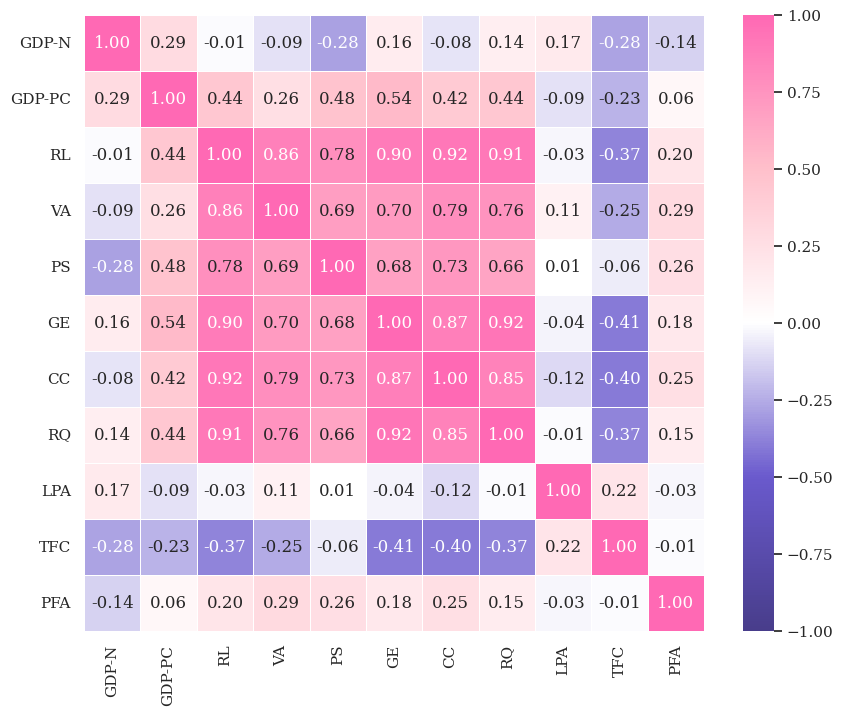


Success! PCA is ready.


In [219]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, QuantileTransformer, MinMaxScaler
from sklearn.decomposition import PCA
import seaborn as sns
import matplotlib.pyplot as plt

# LOAD DATA
gdp_df = gdp.copy()
gdp_pc_df = gdp_pc.copy()
deforestation_df = pd.read_csv(r'D:\deforestation_cleaned_csv_MASK.csv')
protected_df = pd.read_csv(r'D:\forest_protection_stats_FORESTED_MASK_CONIC.csv')
wgi_df = wgi_final.copy()

# CLEAN
print("Cleaning data types and country names...")

country_corrections = {
    'Cabo Verde': 'Cape Verde', 'Congo, Dem. Rep.': 'Democratic Republic of the Congo',
    'Congo, Rep.': 'Congo', "Cote d'Ivoire": "Côte d'Ivoire", "C?te d'Ivoire":"Côte d'Ivoire",
    'Egypt, Arab Rep.': 'Egypt', 'Eswatini': 'Swaziland',
    'Gambia, The': 'Gambia', 'Somalia, Fed. Rep.': 'Somalia',
    'Tanzania': 'United Republic of Tanzania'
}

# Apply corrections
dfs = [gdp_df, gdp_pc_df, wgi_df, deforestation_df, protected_df]
for d in dfs:
    if 'Country Name' in d.columns: d.rename(columns={'Country Name': 'Country'}, inplace=True)
    if 'ADM0_NAME' in d.columns: d.rename(columns={'ADM0_NAME': 'Country'}, inplace=True)
    d['Country'] = d['Country'].replace(country_corrections)

# Force pixel columns to be numeric (removes commas/text)
def to_num(col): return pd.to_numeric(col.astype(str).str.replace(',', ''), errors='coerce')

protected_df['Total_Forest_Pixels'] = to_num(protected_df['Total_Forest_Pixels'])
protected_df['Protected_Forest_Pixels'] = to_num(protected_df['Protected_Forest_Pixels'])
protected_df['Percent_Protected'] = to_num(protected_df['Percent_Protected'])

# DERIVE VARIABLES
print("Calculating Forest Cover and Logging Severity...")

# A. Forest Cover %
forest_cover = pd.merge(protected_df[['Country', 'Total_Land_Pixels']], 
                        protected_df[['Country', 'Total_Forest_Pixels']], on='Country')
forest_cover['Percent_Forest_Cover'] = (protected_df['Total_Forest_Pixels'] / protected_df['Total_Land_Pixels']) * 100

print(forest_cover)

# B. Logging in PAs
logging_math = pd.merge(deforestation_df, protected_df[['Country', 'Protected_Forest_Pixels']], on='Country')
logging_math['Deforestation'] = pd.to_numeric(logging_math['Deforestation'], errors='coerce')
logging_math['Percent_Protected_Logged'] = (logging_math['Deforestation'] / logging_math['Protected_Forest_Pixels']) * 100
logging_math['Percent_Protected_Logged'] = logging_math['Percent_Protected_Logged'].replace([np.inf, -np.inf], np.nan).dropna()

# BIG MERGE
print("Merging all datasets into Master DF...")
df = pd.merge(gdp_df, gdp_pc_df, on=['Country', 'Year'], how='inner')
df = pd.merge(df, wgi_df, on=['Country', 'Year'], how='inner')
df = pd.merge(df, logging_math[['Country', 'Year', 'Percent_Protected_Logged']], on=['Country', 'Year'], how='inner')
df = pd.merge(df, forest_cover[['Country', 'Percent_Forest_Cover']], on='Country', how='left')
df = pd.merge(df, protected_df[['Country', 'Percent_Protected']], on='Country', how='left')

# Forward fill missing years for each country
df = df.sort_values(['Country', 'Year'])
df = df.set_index('Country').groupby('Country').ffill().reset_index()

# PREPARE FOR PCA 
# Copy for math so we keep the original DF just in case
analysis_df = df.copy()

# Drop NA
analysis_df= analysis_df.dropna()

# Select only numbers and drop Year
analysis_df = analysis_df.select_dtypes(include=[np.number]).drop(columns=['Year'], errors='ignore')

# HANDLE SKEWNESS
log_cols = ['GDP_x', 'GDP_y', 'Percent_Protected']#, 'Percent_Forest_Cover']
for col in log_cols:
    if col in analysis_df.columns:
        analysis_df[col] = np.log1p(analysis_df[col])

if 'Percent_Protected_Logged' in analysis_df.columns:
    qt = QuantileTransformer(output_distribution='normal', random_state=42)
    analysis_df['Percent_Protected_Logged'] = qt.fit_transform(analysis_df[['Percent_Protected_Logged']])

# RUN PCA
scaler = StandardScaler()

# this turns everything into positive decimals
scaled_data = scaler.fit_transform(analysis_df)

# Convert back to a DF briefly just to check
scaled_df = pd.DataFrame(scaled_data, columns=analysis_df.columns)
print("\nSCALED DATA PREVIEW (0 to 1)")
print(scaled_df.describe().loc[['min', 'max']])

pca = PCA(n_components=0.95)
pca_results = pca.fit_transform(scaled_data)

# VISUALISE
# Create a dictionary
natural_language_map = {
    'GDP_x': 'GDP-N',
    'GDP_y': 'GDP-PC',
    'Percent_Protected': 'PFA',
    'Percent_Forest_Cover': 'TFC',
    'Percent_Protected_Logged': 'LPA',
    'cc': 'CC',
    'va': 'VA',
    'pv': 'PS',
    'rq': 'RQ',
    'ge': 'GE',
    'rl':'RL'
}

heatmap_data = analysis_df.rename(columns=natural_language_map)

sns.set_theme(style="white", font="serif")
plt.figure(figsize=(10, 8))
pink_white_black = sns.blend_palette(["darkslateblue", "slateblue", "white","pink", "hotpink"], n_colors=256, as_cmap=True)
abs_max = heatmap_data.corr().abs().max().max()
sns.heatmap(heatmap_data.corr(), annot=True, cmap=pink_white_black, fmt=".2f", linewidths=0.5, center=0,        # Forces the middle color to 0
            vmin=-abs_max,         # Ensures the scale is balanced
            vmax=abs_max)          # Ensures the scale is balanced)
#plt.title("Correlation Matrix: Environment vs Economics", fontsize=16, fontweight='bold', pad=15)
plt.savefig(r'c:\Users\terez\OneDrive\Plocha\BTR\Latex_Outputs\Pearson_Correlation_Matrix_Short.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("\nSuccess! PCA is ready.")

In [21]:
print(analysis_df)

          GDP_x     GDP_y         rl         va         pv         ge  \
0     25.396530  8.081516  44.169685  44.517987  51.241035  38.026452   
1     25.536135  8.205672  43.674394  44.484855  47.866182  37.049752   
2     25.682487  8.335300  44.308687  43.881066  47.779428  36.724100   
3     25.918353  8.552931  43.982875  43.213119  48.872710  37.255954   
4     25.736014  8.351476  43.208216  41.829067  45.732287  37.761123   
...         ...       ...        ...        ...        ...        ...   
1010  24.188387  7.630789  35.583189  36.382480  48.027695  29.460455   
1011  24.443830  7.868868  35.216784  36.259154  48.498155  29.961860   
1012  24.430907  7.838895  34.581747  35.984662  51.783282  29.956671   
1013  24.303217  7.694495  35.138935  35.804252  48.843301  32.120461   
1014  24.449908  7.823327  36.123561  34.803724  48.518337  32.136983   

             cc         rq  Percent_Protected_Logged  Percent_Forest_Cover  \
0     35.274080  45.015273                  0

translating

In [22]:
# cHECK IF TRANSLATIONS WERE SUCCESFLU (BELOW)
wb_countries = set(gdp_df['Country'].unique())
gis_countries = set(protected_df['Country'].unique())

print("🕵️ COUNTRIES IN WORLD BANK BUT MISSING FROM GIS:")
print(sorted(wb_countries - gis_countries))

print("\n🌍 COUNTRIES IN GIS BUT MISSING FROM WORLD BANK:")
print(sorted(gis_countries - wb_countries))

🕵️ COUNTRIES IN WORLD BANK BUT MISSING FROM GIS:
[]

🌍 COUNTRIES IN GIS BUT MISSING FROM WORLD BANK:
['Abyei', "Hala'ib triangle", 'Ilemi triangle', "Ma'tan al-Sarra", 'Western Sahara']


summary stats

In [23]:
# 1. Get the standard summary statistics
summary_stats = scaled_df.describe()

# Round it to 2 decimal places so it's easy to read, and transpose (.T) 
# it so the columns go down the side (much easier for large datasets)
print("\nSUMMARY STATISTICS")
print(summary_stats.round(2).T)
# 3. Visual Distributions
# # corner=True removes the duplicate top half of the grid to save rendering time
# sns.pairplot(analysis_df, corner=True, diag_kind='kde')
# plt.show()


SUMMARY STATISTICS
                          count  mean  std   min   25%   50%   75%   max
GDP_x                     954.0  -0.0  1.0 -2.09 -0.61 -0.06  0.60  2.55
GDP_y                     954.0   0.0  1.0 -2.29 -0.73 -0.23  0.81  2.56
rl                        954.0   0.0  1.0 -2.16 -0.74 -0.12  0.57  2.74
va                        954.0   0.0  1.0 -2.17 -0.76 -0.13  0.68  2.34
pv                        954.0  -0.0  1.0 -2.36 -0.68  0.11  0.60  2.26
ge                        954.0  -0.0  1.0 -2.59 -0.71 -0.05  0.56  2.85
cc                        954.0   0.0  1.0 -2.27 -0.79 -0.06  0.53  2.88
rq                        954.0   0.0  1.0 -2.40 -0.71 -0.05  0.49  3.11
Percent_Protected_Logged  954.0  -0.0  1.0 -5.11 -0.66  0.00  0.66  5.11
Percent_Forest_Cover      954.0  -0.0  1.0 -1.36 -1.19  0.22  1.00  1.26
Percent_Protected         954.0   0.0  1.0 -2.26 -0.69 -0.04  0.67  2.34


In [24]:
print(analysis_df)

          GDP_x     GDP_y         rl         va         pv         ge  \
0     25.396530  8.081516  44.169685  44.517987  51.241035  38.026452   
1     25.536135  8.205672  43.674394  44.484855  47.866182  37.049752   
2     25.682487  8.335300  44.308687  43.881066  47.779428  36.724100   
3     25.918353  8.552931  43.982875  43.213119  48.872710  37.255954   
4     25.736014  8.351476  43.208216  41.829067  45.732287  37.761123   
...         ...       ...        ...        ...        ...        ...   
1010  24.188387  7.630789  35.583189  36.382480  48.027695  29.460455   
1011  24.443830  7.868868  35.216784  36.259154  48.498155  29.961860   
1012  24.430907  7.838895  34.581747  35.984662  51.783282  29.956671   
1013  24.303217  7.694495  35.138935  35.804252  48.843301  32.120461   
1014  24.449908  7.823327  36.123561  34.803724  48.518337  32.136983   

             cc         rq  Percent_Protected_Logged  Percent_Forest_Cover  \
0     35.274080  45.015273                  0

supervariable governance

In [25]:
df_full = df.copy()
df_full = df_full.dropna()
print(df_full)

summary_stats = df_full.describe()

# Round it to 2 decimal places so it's easy to read, and transpose (.T) 
# it so the columns go down the side (much easier for large datasets)
print("\nSUMMARY STATISTICS")
print(summary_stats.round(2).T)

       Country  Year         GDP_x        GDP_y         rl         va  \
0      Algeria  2005  1.070466e+11  3233.133396  44.169685  44.517987   
1      Algeria  2006  1.230843e+11  3660.661047  43.674394  44.484855   
2      Algeria  2007  1.424827e+11  4167.451699  44.308687  43.881066   
3      Algeria  2008  1.803838e+11  5180.918815  43.982875  43.213119   
4      Algeria  2009  1.503173e+11  4235.429905  43.208216  41.829067   
...        ...   ...           ...          ...        ...        ...   
1010  Zimbabwe  2020  3.198033e+10  2059.674454  35.583189  36.382480   
1011  Zimbabwe  2021  4.128767e+10  2613.605421  35.216784  36.259154   
1012  Zimbabwe  2022  4.075756e+10  2536.400502  34.581747  35.984662   
1013  Zimbabwe  2023  3.587178e+10  2195.224921  35.138935  35.804252   
1014  Zimbabwe  2024  4.153941e+10  2497.203322  36.123561  34.803724   

             pv         ge         cc         rq  Percent_Protected_Logged  \
0     51.241035  38.026452  35.274080  45.015

make state capacity index

In [26]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

df_stats_copy = df_full.copy()

# 2. Select a REDUCED set of variables (Avoid using all cc, rl, va at once!)
# Pick the 'best' representatives
features = ['cc', 'rl', 'va', 'pv', 'rq', 'ge']
X = df_stats_copy[features]
X = sm.add_constant(X)

# 3. Check for multicollinearity (VIF)
# If VIF > 5, the variable is too correlated with others
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("--- VIF Scores (Aim for < 5) ---")
print(vif_data)


# RUN PCA TO CREATE 'STATE CAPACITY INDEX'
print("Building State Capacity Index...")

# 1. Define ONLY the WGI columns that measure institutional strength
wgi_cols = ['rl', 'cc', 'ge', 'rq'] 

# 2. Isolate these columns from your clean dataset
wgi_data = df_full[wgi_cols]

--- VIF Scores (Aim for < 5) ---
  feature        VIF
0   const  48.705260
1      cc   7.061865
2      rl  18.294584
3      va   4.353081
4      pv   2.676031
5      rq   9.549078
6      ge   9.109742
Building State Capacity Index...


new version of makign the state capacity index supervariable through PCA (better due to standard scaler)

In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# 1. Standardize 
# standard scaler is necessary for PCA
# choosing variables based on VIF above
pca_scaler = StandardScaler()
scaled_wgi = pca_scaler.fit_transform(wgi_data)

# 2. Run PCA
pca = PCA(n_components=1)
state_capacity_raw = pca.fit_transform(scaled_wgi)

# 3. If the correlation with 'rl' is negative, flip the index
if pca.components_[0][0] < 0:
    state_capacity_raw = state_capacity_raw * -1

# 4. MAKE IT NON-NEGATIVE (The "0 to 1" step)
final_scaler = MinMaxScaler()
# This shifts the whole index so the worst country is 0 and the best is 100 (such that we have it aligning with va and pv, otherwise it would have been 0-1)
# this is why we have *100 there
df_stats_copy['State_Capacity_Index'] = final_scaler.fit_transform(state_capacity_raw)*100

print(f"Index Range: {df_stats_copy['State_Capacity_Index'].min()} to {df_stats_copy['State_Capacity_Index'].max()}")

Index Range: 0.0 to 100.0


In [28]:
# 1. Get the standard summary statistics
summary= df_stats_copy.describe()

# Round it to 2 decimal places so it's easy to read, and transpose (.T) 
# it so the columns go down the side (much easier for large datasets)
print("\nSUMMARY STATISTICS")
print(summary.round(2).T)


SUMMARY STATISTICS
                          count          mean           std           min  \
Year                      954.0  2.014540e+03  5.760000e+00  2.005000e+03   
GDP_x                     954.0  4.679269e+10  9.430397e+10  6.347819e+08   
GDP_y                     954.0  2.531140e+03  3.125570e+03  1.472300e+02   
rl                        954.0  4.551000e+01  1.065000e+01  2.254000e+01   
va                        954.0  4.640000e+01  1.170000e+01  2.108000e+01   
pv                        954.0  5.573000e+01  1.420000e+01  2.220000e+01   
ge                        954.0  3.871000e+01  1.195000e+01  7.740000e+00   
cc                        954.0  3.545000e+01  1.295000e+01  6.060000e+00   
rq                        954.0  4.486000e+01  8.980000e+00  2.330000e+01   
Percent_Protected_Logged  954.0  2.800000e-01  5.700000e-01  0.000000e+00   
Percent_Forest_Cover      954.0  5.163000e+01  3.785000e+01  0.000000e+00   
Percent_Protected         954.0  2.310000e+01  1.935000e

In [29]:
print(df_stats_copy)

       Country  Year         GDP_x        GDP_y         rl         va  \
0      Algeria  2005  1.070466e+11  3233.133396  44.169685  44.517987   
1      Algeria  2006  1.230843e+11  3660.661047  43.674394  44.484855   
2      Algeria  2007  1.424827e+11  4167.451699  44.308687  43.881066   
3      Algeria  2008  1.803838e+11  5180.918815  43.982875  43.213119   
4      Algeria  2009  1.503173e+11  4235.429905  43.208216  41.829067   
...        ...   ...           ...          ...        ...        ...   
1010  Zimbabwe  2020  3.198033e+10  2059.674454  35.583189  36.382480   
1011  Zimbabwe  2021  4.128767e+10  2613.605421  35.216784  36.259154   
1012  Zimbabwe  2022  4.075756e+10  2536.400502  34.581747  35.984662   
1013  Zimbabwe  2023  3.587178e+10  2195.224921  35.138935  35.804252   
1014  Zimbabwe  2024  4.153941e+10  2497.203322  36.123561  34.803724   

             pv         ge         cc         rq  Percent_Protected_Logged  \
0     51.241035  38.026452  35.274080  45.015

OLS regression: finally something is working!!! OLS regression has shown that indeed VA and PV are not that amazing predictors (high p value)


the narrative: governance dictates how iclined to defect the state is. GDP_y defines the pressure to defect as well as the payoff for the state when it defects (i.e. bags the funds). 'Percent_Protected' is what the donor wants to maximise effectively, as well as the cost of enforcement for the government. better governance is however showing higher deforestation in PAs, which can mean *reporing bias*

In [30]:
core_vars = ['Percent_Protected_Logged', 'GDP_y', 'cc', 'rl', 'Percent_Protected', 'State_Capacity_Index', 'GDP_x', 'va', 'pv', 'rq', 'ge', 'Percent_Forest_Cover'] 

# # Create a clean dataframe with just these variables, dropping empty rows
stats_df = df_stats_copy[core_vars].dropna()

**BUILDING OLS FROM SCRATCH**

Generating scatter plots with regression lines...


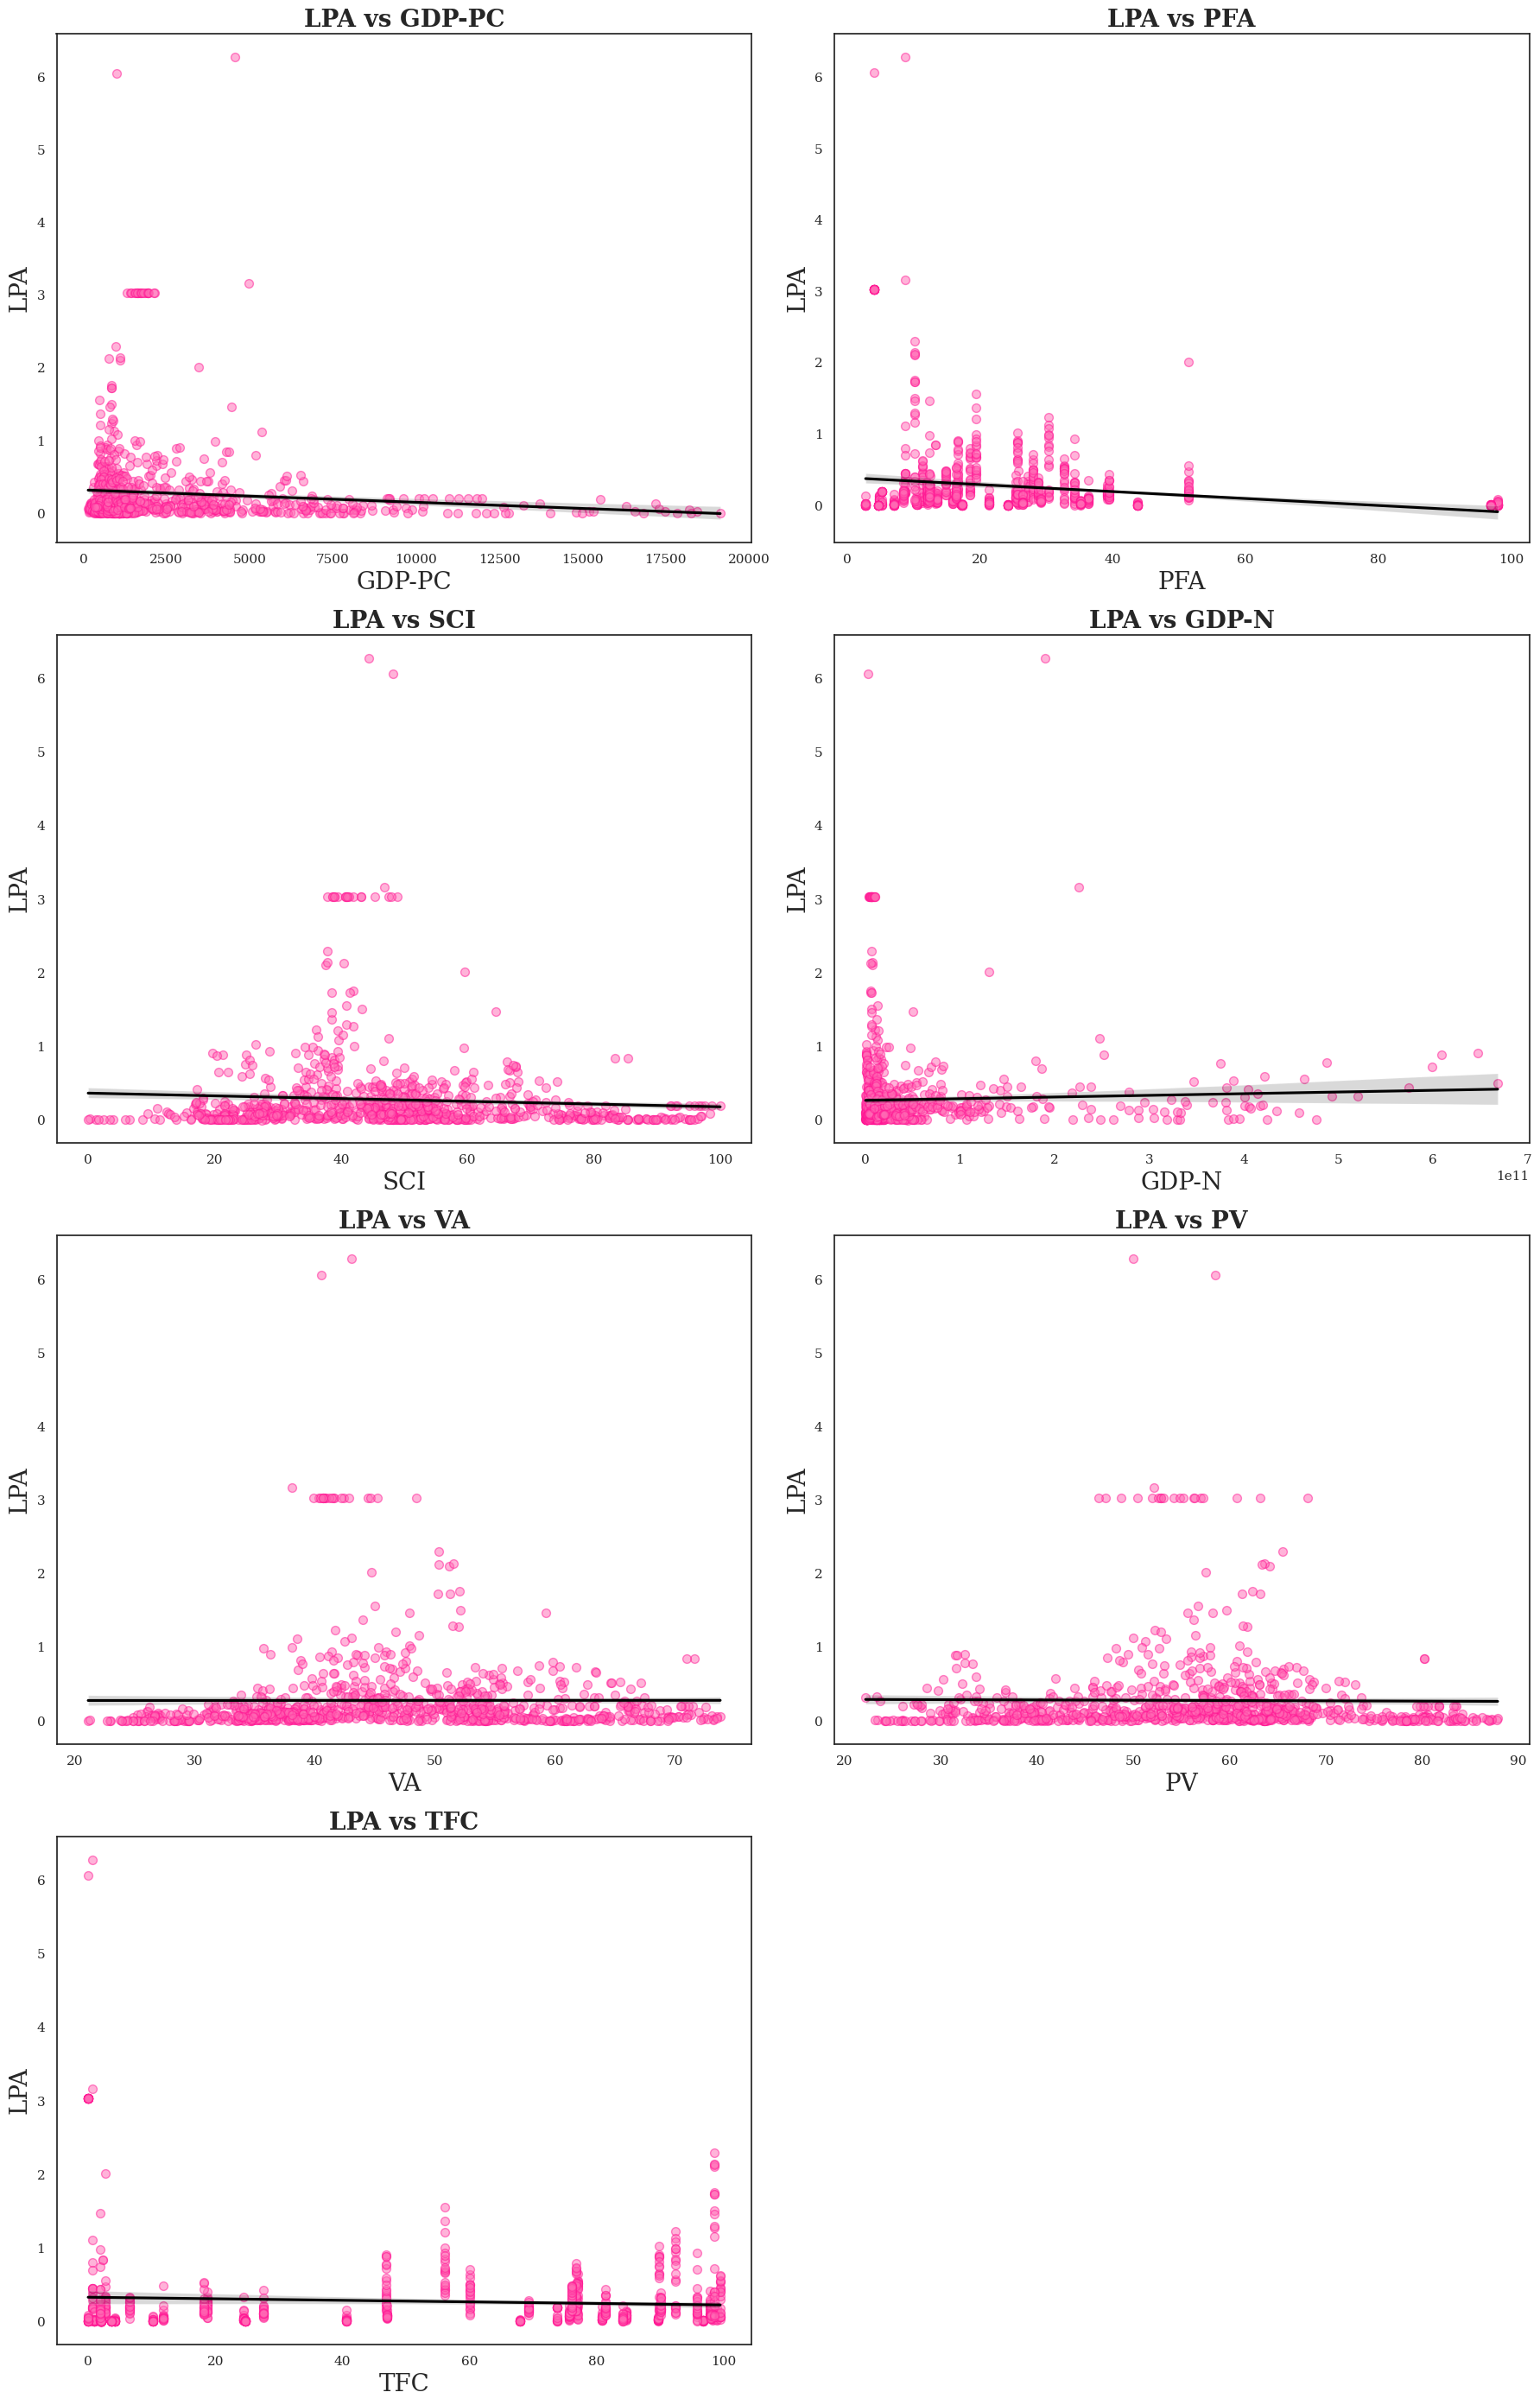

In [229]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. MAP TO NATURAL LANGUAGE
name_map = {
    'Percent_Protected_Logged': 'LPA',
    'GDP_y': 'GDP-PC',
    'cc': 'CC',
    'rl': 'RL',
    'Percent_Protected': 'PFA',
    'State_Capacity_Index': 'SCI',
    'GDP_x': 'GDP-N',
    'va': 'VA',
    'pv': 'PV',
    'rq': 'RQ',
    'ge': 'GE',
    'Percent_Forest_Cover': 'TFC'
}

# Define variables 
dependent_var = 'Percent_Protected_Logged'
independent_vars = ['GDP_y','Percent_Protected', 'State_Capacity_Index', 
                    'GDP_x', 'va', 'pv','Percent_Forest_Cover']

# 2. MAKE IT BONITA
sns.set_theme(style="white", font="serif")

# Create a figure with a grid of subplots
n_cols = 2
n_rows = (len(independent_vars) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 7 * n_rows))
axes = axes.flatten()

print("Generating scatter plots with regression lines...")

for i, col in enumerate(independent_vars):
    # regplot adds the scatter points AND the OLS regression line
    sns.regplot(
        data=stats_df, 
        x=col, 
        y=dependent_var, 
        ax=axes[i],
        # 3. CHANGE DOT COLORS AND SIZES
        scatter_kws={'alpha': 0.5, 's': 50, 'color': 'hotpink', 'edgecolor': 'deeppink'}, 
        line_kws={'color': 'black'} # Make the regression line stand out
    )
    
    # 4. APPLY THE TRANSLATIONS
    # .get() looks up the pretty name
    clean_x = name_map.get(col, col) 
    clean_y = name_map.get(dependent_var, dependent_var)
    
    # labels
    axes[i].set_title(f'{clean_y} vs {clean_x}', fontsize=20, fontweight='bold')
    axes[i].set_xlabel(clean_x, fontsize=20)
    axes[i].set_ylabel(clean_y, fontsize=20)

plt.tick_params(axis='both', which='major', labelsize=20)

# Remove any empty subplots at the bottom
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig(r"c:\Users\terez\OneDrive\Plocha\BTR\THESIS\Figures\Variable_dist.pdf", dpi=300, bbox_inches='tight')
plt.show()

this is just to orient oneself within and for analystics

In [215]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import numpy as np

# 1. Feature Engineering
# Log-transform skewed predictors
stats_df['Log_GDP'] = np.log1p(stats_df['GDP_y'])
stats_df['Log_Forest'] = np.log1p(stats_df['Percent_Forest_Cover'])
stats_df['Log_Logged'] = np.log1p(df['Percent_Protected_Logged'])
stats_df['Log_Protected'] = np.log1p(df['Percent_Protected'])

# 2. Select a REDUCED set of variables
# Pick the 'best' representatives
features = ['State_Capacity_Index', 'Log_Forest', 'va', 'pv', 'GDP_x_scaled', 'Log_Protected', 'Log_GDP']
X = stats_df[features]
X = sm.add_constant(X)
Y = stats_df['Percent_Protected_Logged']

# 3. Check for Multicollinearity (VIF)
# If VIF > 5, the variable is too correlated with others
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
print("--- VIF Scores (Aim for < 5) ---")
print(vif_data)

# 4. Fit the Final Model
final_model = sm.OLS(Y, X).fit()
print(final_model.summary())

--- VIF Scores (Aim for < 5) ---
                feature         VIF
0                 const  449.668622
1  State_Capacity_Index    4.861508
2            Log_Forest    1.267586
3                    va    3.546370
4                    pv    3.952837
5          GDP_x_scaled    1.646935
6         Log_Protected    1.124296
7               Log_GDP    1.910948
                               OLS Regression Results                               
Dep. Variable:     Percent_Protected_Logged   R-squared:                       0.131
Model:                                  OLS   Adj. R-squared:                  0.124
Method:                       Least Squares   F-statistic:                     20.31
Date:                      Thu, 07 May 2026   Prob (F-statistic):           1.62e-25
Time:                              11:37:43   Log-Likelihood:                -747.46
No. Observations:                       954   AIC:                             1511.
Df Residuals:                           946   BI

this relies on the variables from the above chunk

**MARKER!!!!!!**

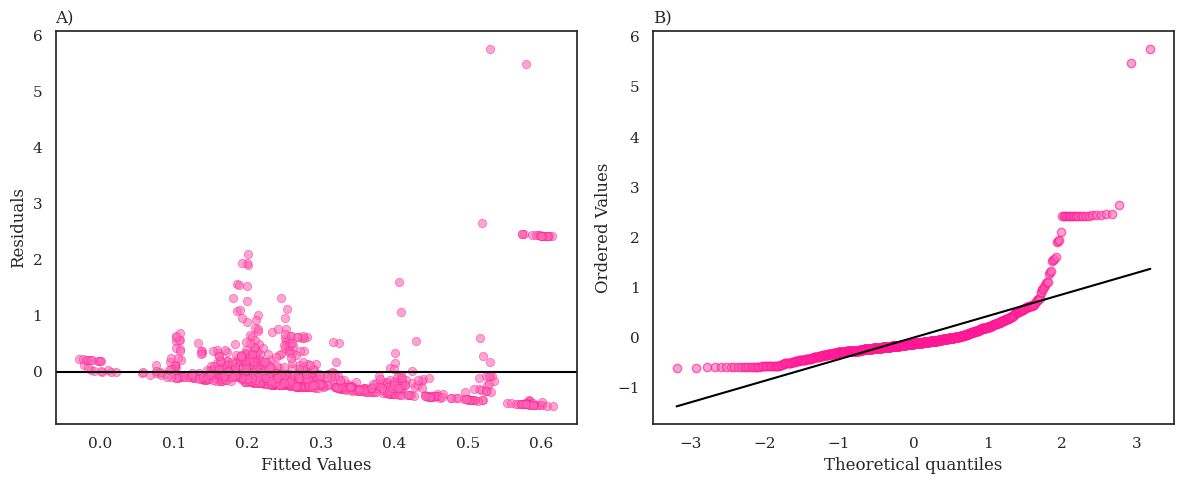

In [208]:
import scipy.stats as stats

# Get the residuals
residuals = final_model.resid
fitted_values = final_model.fittedvalues

plt.figure(figsize=(12, 5))

# Plot 1: Residuals vs Fitted (Checks for heteroscedasticity = "a situation in statistics where the variance of residuals (error terms) is 
# not constant across all observations in a regression model, violating the ordinary least squares (OLS) assumption of homoscedasticity")
plt.subplot(1, 2, 1)
sns.scatterplot(alpha= 0.6, x=fitted_values, y=residuals, color='hotpink', edgecolor='deeppink')

plt.axhline(0, color='black')
#plt.title('Residuals vs OLS Fitted Values', fontsize=12, fontweight='bold')
plt.title('A)', loc='left')
# (Should be a random cloud)
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

# Plot 2: Q-Q Plot (Checks for Normality of Errors)
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)

ax = plt.gca()
ax.set_title("")
plt.title('B)', loc='left')
lines = ax.get_lines()

# lines[0] are the scatter plot points 
lines[0].set_markerfacecolor('hotpink') 
lines[0].set_markeredgecolor('deeppink')
lines[0].set_alpha(0.6)

# lines[1] is the regression line
lines[1].set_color('black')

#plt.title('Normal Q-Q Plot', fontsize=12, fontweight='bold')
#(Should follow the purple line)

plt.tight_layout()

# Save the figure as a PDF

plt.savefig(r"c:\Users\terez\OneDrive\Plocha\BTR\THESIS\Figures\OLS_Analysis.pdf", dpi=300, bbox_inches='tight')
plt.show()



The results of the logit model explain the features of the model - i.e. if there is forest above a certain value, there is protection or something like that (ignore numbers in your analysis)

this is just a checkpoint

In [34]:
# Logistic Regression (Is there ANY forest?)
'''
stats_df['has_forest'] = (stats_df['Percent_Forest_Cover'] > 0).astype(int)
logit_model = sm.Logit(stats_df['has_forest'], X).fit()
print("LOGIT RESULTS (probability of having any protection)")
print(logit_model.summary())
'''

'\nstats_df[\'has_forest\'] = (stats_df[\'Percent_Forest_Cover\'] > 0).astype(int)\nlogit_model = sm.Logit(stats_df[\'has_forest\'], X).fit()\nprint("LOGIT RESULTS (probability of having any protection)")\nprint(logit_model.summary())\n'

check there are no zeros or weird values over 100%

In [35]:
print(stats_df)

      Percent_Protected_Logged        GDP_y         cc         rl  \
0                     0.186376  3233.133396  35.274080  44.169685   
1                     0.200849  3660.661047  38.874555  43.674394   
2                     0.403525  4167.451699  38.152088  44.308687   
3                     0.803912  5180.918815  36.074908  43.982875   
4                     0.453597  4235.429905  35.403077  43.208216   
...                        ...          ...        ...        ...   
1010                  0.069969  2059.674454  24.112562  35.583189   
1011                  0.098670  2613.605421  23.832533  35.216784   
1012                  0.090368  2536.400502  23.595848  34.581747   
1013                  0.055417  2195.224921  23.737832  35.138935   
1014                  0.060450  2497.203322  22.519426  36.123561   

      Percent_Protected  State_Capacity_Index         GDP_x         va  \
0                  8.71             46.328575  1.070466e+11  44.517987   
1                  8.71

the actual DF :)

In [36]:
print("min")
stats_df.min(axis='rows')  

min


Percent_Protected_Logged    3.836936e-05
GDP_y                       1.472346e+02
cc                          6.061704e+00
rl                          2.254037e+01
Percent_Protected           2.770000e+00
State_Capacity_Index        0.000000e+00
GDP_x                       6.347819e+08
va                          2.107796e+01
pv                          2.220234e+01
rq                          2.329758e+01
ge                          7.735593e+00
Percent_Forest_Cover        5.456175e-05
Log_GDP                     4.998796e+00
Log_Forest                  5.456026e-05
Log_Logged                  3.836863e-05
Log_Protected               1.327075e+00
dtype: float64

this is a double check (should match the actual DF)

In [37]:
print("min")
df_stats_copy.min(axis='rows')  

min


Country                              Algeria
Year                                    2005
GDP_x                       634781901.251494
GDP_y                             147.234619
rl                                 22.540368
va                                 21.077957
pv                                  22.20234
ge                                  7.735593
cc                                  6.061704
rq                                 23.297577
Percent_Protected_Logged            0.000038
Percent_Forest_Cover                0.000055
Percent_Protected                       2.77
State_Capacity_Index                     0.0
dtype: object

In [196]:
print("Countries with the minimum values:")
# Temporarily set Country as the index, then find the index of the minimums
df_stats_copy = df_stats_copy.dropna()
min_countries = df_stats_copy.set_index('Country').idxmin()

print(min_countries)

# Identify numeric columns only (to avoid errors with text columns)
numeric_cols = df_stats_copy.select_dtypes(include=['number']).columns

for col in numeric_cols:
    idx = df_stats_copy[col].idxmin()
    row = df_stats_copy.loc[idx]
    print(f"Column: {col} | Min is in {row['Country']} ({row['Year']}): {row[col]}")

    # Returns the top 3 rows based on a specific column
top_3 = df_stats_copy.nsmallest(60, 'Percent_Protected_Logged')

# Select only the columns you care about to make it readable
print(top_3[['Country', 'Year', 'Percent_Protected_Logged']])

Countries with the minimum values:
Year                              Algeria
GDP_x                       Guinea-Bissau
GDP_y                             Burundi
rl                            South Sudan
va                            South Sudan
pv                                   Mali
ge                            South Sudan
cc                            South Sudan
rq                            South Sudan
Percent_Protected_Logged            Sudan
Percent_Forest_Cover           Mauritania
Percent_Protected                   Egypt
State_Capacity_Index          South Sudan
dtype: object
Column: Year | Min is in Algeria (2005): 2005
Column: GDP_x | Min is in Guinea-Bissau (2006): 634781901.2514939
Column: GDP_y | Min is in Burundi (2005): 147.2346192942251
Column: rl | Min is in South Sudan (2023): 22.5403676
Column: va | Min is in South Sudan (2018): 21.0779569
Column: pv | Min is in Mali (2023): 22.2023396
Column: ge | Min is in South Sudan (2021): 7.7355934
Column: cc | Min is in So

the actual df

In [39]:
print("max")
stats_df.max(axis='rows')

max


Percent_Protected_Logged    6.281877e+00
GDP_y                       1.914151e+04
cc                          7.276802e+01
rl                          7.467189e+01
Percent_Protected           9.799000e+01
State_Capacity_Index        1.000000e+02
GDP_x                       6.682200e+11
va                          7.380739e+01
pv                          8.782743e+01
rq                          7.279937e+01
ge                          7.273938e+01
Percent_Forest_Cover        9.944700e+01
Log_GDP                     9.859667e+00
Log_Forest                  4.609630e+00
Log_Logged                  1.985389e+00
Log_Protected               4.595019e+00
dtype: float64

this is a double check (should match the actual DF)

In [40]:
print("max")
df_stats_copy.max(axis='rows')

max


Country                                Zimbabwe
Year                                       2024
GDP_x                       668219992691.462158
GDP_y                              19141.511874
rl                                    74.671894
va                                    73.807387
pv                                    87.827426
ge                                    72.739377
cc                                    72.768021
rq                                    72.799375
Percent_Protected_Logged               6.281877
Percent_Forest_Cover                     99.447
Percent_Protected                         97.99
State_Capacity_Index                      100.0
dtype: object

In [195]:
print("Countries with the maximum values:")
# Temporarily set Country as the index, then find the index of the maxima
df_stats_copy = df_stats_copy.dropna()
max_countries = df_stats_copy.set_index('Country').idxmax()

print(max_countries)

# Identify numeric columns only (to avoid errors with text columns)
numeric_cols = df_stats_copy.select_dtypes(include=['number']).columns

for col in numeric_cols:
    idx = df_stats_copy[col].idxmax()
    row = df_stats_copy.loc[idx]
    print(f"Column: {col} | Max is in {row['Country']} ({row['Year']}): {row[col]}")

    # Returns the top 3 rows based on a specific column
top_3 = df_stats_copy.nlargest(55, 'State_Capacity_Index')

# Select only the columns you care about to make it readable
print(top_3[['Country', 'Year', 'State_Capacity_Index']])

Countries with the maximum values:
Year                           Algeria
GDP_x                          Nigeria
GDP_y                       Seychelles
rl                           Mauritius
va                          Cape Verde
pv                            Botswana
ge                           Mauritius
cc                          Seychelles
rq                           Mauritius
Percent_Protected_Logged       Algeria
Percent_Forest_Cover           Liberia
Percent_Protected                Niger
State_Capacity_Index         Mauritius
dtype: object
Column: Year | Max is in Algeria (2024): 2024
Column: GDP_x | Max is in Nigeria (2019): 668219992691.4622
Column: GDP_y | Max is in Seychelles (2019): 19141.5118743615
Column: rl | Max is in Mauritius (2012): 74.67189429999999
Column: va | Max is in Cape Verde (2008): 73.80738699999999
Column: pv | Max is in Botswana (2007): 87.8274261
Column: ge | Max is in Mauritius (2016): 72.73937699999999
Column: cc | Max is in Seychelles (2024): 72.76

In [42]:
print(stats_df['Percent_Forest_Cover'])

0        0.731894
1        0.731894
2        0.731894
3        0.731894
4        0.731894
          ...    
1010    47.036460
1011    47.036460
1012    47.036460
1013    47.036460
1014    47.036460
Name: Percent_Forest_Cover, Length: 954, dtype: float64


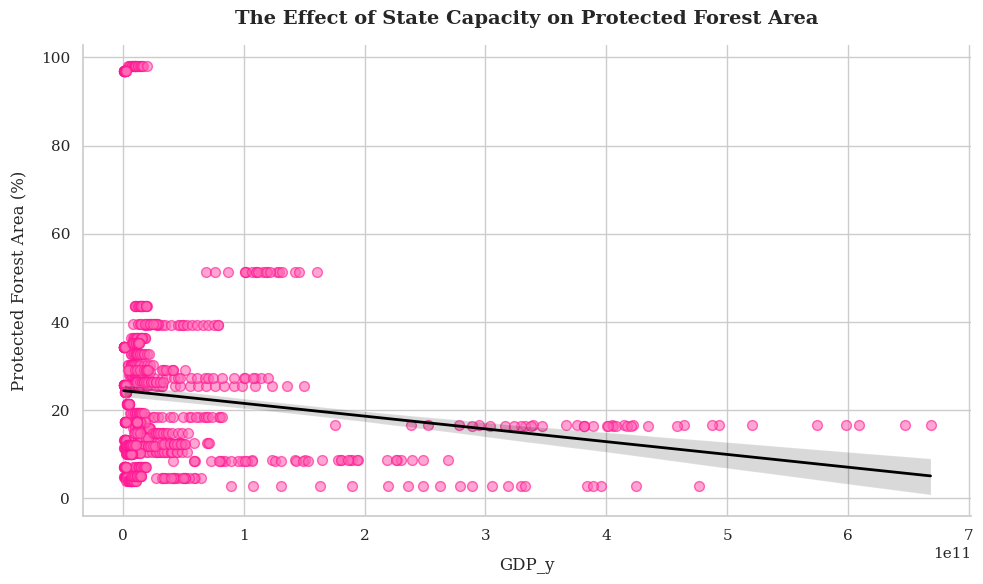

In [95]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_theme(style="whitegrid", font="serif")
plt.figure(figsize=(10, 6))

# Create the scatter plot with a regression line
ax = sns.regplot(
    data=stats_df, 
    x='GDP_x',   
    y='Percent_Protected',     
    scatter_kws={'alpha': 0.6, 'color': 'hotpink', 'edgecolor': 'deeppink', 's': 50}, # Styles the dots
    line_kws={'color': 'black', 'linewidth': 2}                              # Styles the trend line
)

# Add labels
plt.title("The Effect of State Capacity on Protected Forest Area", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("GDP_y", fontsize=12, labelpad=10)
plt.ylabel("Protected Forest Area (%)", fontsize=12, labelpad=10)

# Clean up the borders
sns.despine()

# Show the plot
plt.tight_layout()
plt.show()

variables starting 'Log' or ending 'scaled' are just log-transformed

also, this is the GLM and we try new models due to **MARKER!!!!!** (above). we first tried the NEGATIVE BINOMIAL  and then the GAMMA linear models. GAMMA works better for our data baecause:

* we do not have zeros or negatives
* data are not counts

In [47]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# 1. Prepare features (the same X used in the model)
X = stats_df[['State_Capacity_Index', 'Log_Forest', 'va', 'pv', 'GDP_x_scaled', 'Log_GDP','Log_Protected']]
X['const'] = 1 # VIF calculation requires a constant

# 2. Calculate VIF for each variable
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

# 3. View results
print(vif_data[vif_data['feature'] != 'const'].sort_values(by="VIF", ascending=False))

                feature       VIF
0  State_Capacity_Index  4.861508
3                    pv  3.952837
2                    va  3.546370
5               Log_GDP  1.910948
4          GDP_x_scaled  1.646935
1            Log_Forest  1.267586
6         Log_Protected  1.124296


C:\Users\terez\AppData\Local\Temp\ipykernel_14036\4068449059.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['const'] = 1 # VIF calculation requires a constant


In [199]:
import statsmodels.api as sm
import numpy as np
from sklearn.preprocessing import StandardScaler, QuantileTransformer, MinMaxScaler

stats_df['GDP_x_scaled'] = np.log1p(stats_df['GDP_x'])
stats_df['Log_Percent_Protected_Logged'] = np.log1p(stats_df['GDP_x'])

print("-----------------------------------------------------")
print("GAMMA REGRESSION RESULTS")
print("-----------------------------------------------------")

import statsmodels.api as sm

# 1. DATA CLEANING FOR GAMMA
# Gamma cannot handle 0 or negative values. 
# Tiny epsilon - changing the order to check robustness
epsilon = 1e-12
Y_gamma = stats_df['Percent_Protected_Logged'] + epsilon


# 2. SELECT FEATURES
X_gamma = stats_df[['State_Capacity_Index', 'Log_Forest', 'va', 'pv', 'GDP_x_scaled', 'Log_Protected', 'Log_GDP']] 
X_gamma = sm.add_constant(X_gamma)

#deleting GDP_x throws the model off but deleting GDP_y does not? (in terms of p-val)
# now it has slightly higher r^2 and log likelihood, Pearson Chi2 and Scale decreased (this is good, Google why for write up)

# 3. FIT THE GAMMA MODEL 
model_gamma = sm.GLM(
    Y_gamma, 
    X_gamma, 
    family=sm.families.Gamma(link=sm.families.links.Log())
).fit()

print(model_gamma.summary())

-----------------------------------------------------
GAMMA REGRESSION RESULTS
-----------------------------------------------------
                    Generalized Linear Model Regression Results                     
Dep. Variable:     Percent_Protected_Logged   No. Observations:                  954
Model:                                  GLM   Df Residuals:                      946
Model Family:                         Gamma   Df Model:                            7
Link Function:                          Log   Scale:                          1.9436
Method:                                IRLS   Log-Likelihood:                 570.44
Date:                      Mon, 04 May 2026   Deviance:                       1895.5
Time:                              20:15:13   Pearson chi2:                 1.84e+03
No. Iterations:                          98   Pseudo R-squ. (CS):             0.2147
Covariance Type:                  nonrobust                                         
                 

In [62]:
print(stats_df['GDP_x_scaled'].mean(axis='rows')*0.3423)
print(stats_df['Log_GDP'].mean(axis='rows')*-0.3423 ) 
print(stats_df['Log_Forest'].mean(axis='rows')*-0.1930) 
print(stats_df['Log_Protected'].mean(axis='rows')*-0.5601)
print(stats_df['State_Capacity_Index'].mean(axis='rows')*-0.0518)
print(stats_df['va'].mean(axis='rows')*0.0437)
print(stats_df['pv'].mean(axis='rows')*0.0424)


8.010549665617827
-2.497600678197932
-0.640845770339606
-1.6409429374799218
-2.4482933776180076
2.0276534764224214
2.362954825866667


hurdle model, nor zero-inflation, nor tweedie make this better (viz below mixed results on prediction of Gamma)

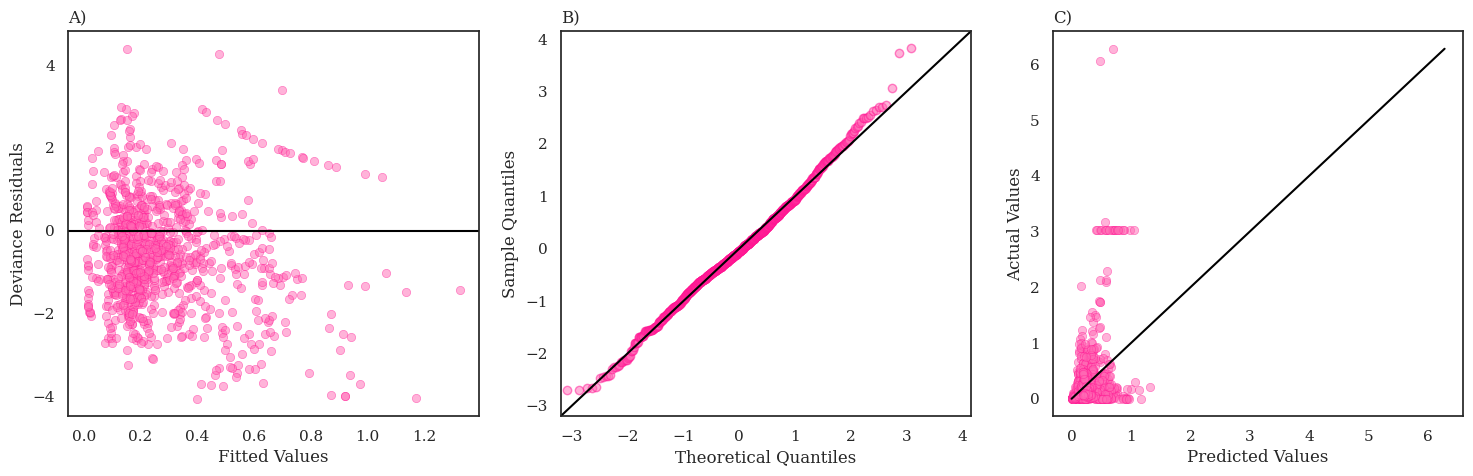

In [200]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Residuals vs. Fitted Values
# Added color='pink' or 'hotpink'
sns.scatterplot(x=model_gamma.fittedvalues, y=model_gamma.resid_deviance, 
                ax=axes[0], alpha=0.5, color='hotpink', edgecolor = 'deeppink')
axes[0].axhline(0, color='black')
#axes[0].set_title('Deviance Residuals vs. Fitted Values')
axes[0].set_title('A)', loc='left')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Deviance Residuals')

# 2. Q-Q Plot of Deviance Residuals
# For statsmodels qqplot, we use markerfacecolor and markeredgecolor
sm.qqplot(model_gamma.resid_deviance, line='45', fit=True, ax=axes[1], 
          markerfacecolor='hotpink', markeredgecolor='deeppink', alpha=0.5)
#axes[1].set_title('Normal Q-Q Plot of Deviance Residuals')
axes[1].set_title('B)', loc = 'left')
axes[1].get_lines()[1].set_color('black') # or 'grey', 'teal', etc.

# 3. Actual vs. Predicted
# Added color='hotpink'
sns.scatterplot(x=model_gamma.fittedvalues, y=Y_gamma, 
                ax=axes[2], alpha=0.5, color='hotpink',  edgecolor='deeppink')
min_val = min(Y_gamma.min(), model_gamma.fittedvalues.min())
max_val = max(Y_gamma.max(), model_gamma.fittedvalues.max())
axes[2].plot([min_val, max_val], [min_val, max_val], color='black')
#axes[2].set_title('Actual vs. Predicted Values')
axes[2].set_title('C)', loc= 'left')
axes[2].set_xlabel('Predicted Values')
axes[2].set_ylabel('Actual Values')

#plt.tight_layout()

# Create a list of filenames
filenames = ['residuals_vs_fitted.pdf', 'qq_plot.pdf', 'actual_vs_predicted.pdf']

# Loop through each axis and save it individually
for i, ax in enumerate(axes):
    # Determine the extent of the subplot
    extent = ax.get_tightbbox(fig.canvas.get_renderer()).transformed(fig.dpi_scale_trans.inverted())
    
    # Save the individual subplot
    # Note: I'm using the same path structure you provided
    path = rf'c:\Users\terez\OneDrive\Plocha\BTR\Latex_Outputs\{filenames[i]}'
    fig.savefig(path, bbox_inches=extent, dpi=300)

plt.show()

How much does an improvement in X guarantee improvement in Y?

**WORK WITH THIS**

raw variables

In [ ]:
import numpy as np
import pandas as pd

# Choose the feature you want to test
feature_to_test = 'pv' 

# Extract the coefficient for the feature
coef = model_gamma.params[feature_to_test]

# Calculate the multiplier and percentage change
multiplier = np.exp(coef)
percent_change = (multiplier - 1) * 100

print(f"\n--- IMPACT OF 1-UNIT INCREASE IN '{feature_to_test}' ---")
print(f"Coefficient (Beta): {coef:.5f}")
print(f"Multiplier (exp(Beta)): {multiplier:.5f}")
print(f"Percentage Change: {percent_change:.2f}%\n")

# To get an absolute number, we need a starting point. 
# the mean of all variables as baseline "average" scenario
baseline_X = pd.DataFrame([X_gamma.mean()])

# Predict Y at baseline
predicted_Y_baseline = model_gamma.predict(baseline_X)[0]

# Create a new scenario, x is increased by 1 unit
new_X = baseline_X.copy()
new_X[feature_to_test] += 1

# Predict Y at the new scenario x
predicted_Y_new = model_gamma.predict(new_X)[0]

# absolute chg.
absolute_change = predicted_Y_new - predicted_Y_baseline

print("--- ABSOLUTE CHANGE (From Mean Baseline) ---")
print(f"Predicted Y at Average Values: {predicted_Y_baseline:.4f}")
print(f"Predicted Y after 1-unit increase in X: {predicted_Y_new:.4f}")
print(f"Absolute Improvement in Y: {absolute_change:.4f} units")


--- IMPACT OF 1-UNIT INCREASE IN 'pv' ---
Coefficient (Beta): 0.02946
Multiplier (exp(Beta)): 1.02990
Percentage Change: 2.99%

--- ABSOLUTE CHANGE (From Mean Baseline) ---
Predicted Y at Average Values: 0.2247
Predicted Y after 1-unit increase in X: 0.2314
Absolute Improvement in Y: 0.0067 units
---------------------------------------------------------


translation for logarithmically transformed variables

In [ ]:
feature_to_test = 'Log_GDP' 
coef = model_gamma.params[feature_to_test]

# Instead of a 1-unit jump in the log (which is huge), calculates a 1% jump in the raw value.
percent_increase_X = 1.01 
multiplier_1pct = percent_increase_X**coef
impact_1pct = (multiplier_1pct - 1) * 100

print(f"--- IMPACT OF 1% INCREASE IN ORIGINAL '{feature_to_test.replace('Log_', '')}' ---")
print(f"Percentage Change in Y: {impact_1pct:.4f}%")

baseline_X = pd.DataFrame([X_gamma.mean()], columns=X_gamma.columns)
predicted_Y_baseline = model_gamma.predict(baseline_X)[0]

# Increase the log variable by the log of 1.01 (which is a 1% increase in raw units)
new_X = baseline_X.copy()
new_X[feature_to_test] += np.log(1.01) 

predicted_Y_new = model_gamma.predict(new_X)[0]
absolute_change = predicted_Y_new - predicted_Y_baseline

print(f"\n--- ABSOLUTE CHANGE (From 1% increase in raw units) ---")
print(f"Absolute change in Y: {absolute_change:.6f}")

--- IMPACT OF 1% INCREASE IN ORIGINAL 'GDP' ---
Percentage Change in Y: -0.3392%

--- ABSOLUTE CHANGE (From 1% increase in raw units) ---
Absolute change in Y: -0.000744


**the game based on GLM**

treecover

In [ ]:
import re

# DOwnload data
raw_data = """.https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_180W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10N_180W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_10S_180W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20N_180W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_20S_180W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30N_180W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_30S_180W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40N_180W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_40S_180W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50N_180W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_50S_180W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_60N_180W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_70N_180W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_040E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_040W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_050E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_050W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_060E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_060W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_070E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_070W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_080E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_080W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_090E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_090W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_100E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_100W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_110E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_110W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_120E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_120W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_130E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_130W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_140E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_140W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_150E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_150W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_160E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_160W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_170E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_170W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_80N_180W.tif..""" # paste your full text here

# 1. Clean the list
urls = [line.strip() for line in raw_data.split('\n') if line.strip()]

def is_comprehensive_africa(url):
    # Extracts coordinates
    match = re.search(r'(\d+)([NS])_(\d+)([EW])', url)
    if not match:
        return False
    
    lat_val, lat_dir, lon_val, lon_dir = match.groups()
    
    # Convert to numeric (North/East positive, South/West negative)
    lat = int(lat_val) * (1 if lat_dir == 'N' else -1)
    lon = int(lon_val) * (1 if lon_dir == 'E' else -1)

    # Latitude: 40N (+40) to 40S (-40)
    # Longitude: 30W (-30) to 60E (+60)
    lat_ok = -40 <= lat <= 40
    lon_ok = -30 <= lon <= 60
    
    return lat_ok and lon_ok

africa_comprehensive = [url for url in urls if is_comprehensive_africa(url)]

# Output
for url in sorted(africa_comprehensive):
    print(url)

print(f"\nSuccessfully filtered to {len(africa_comprehensive)} tiles (including islands).")

.https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_000E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_010E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_010W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_020E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_020W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_030E.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_030W.tif
https://storage.googleapis.com/earthenginepartners-hansen/GFC-2024-v1.12/Hansen_GFC-2024-v1.12_treecover2000_00N_040E.tif
https://storage.googlea

In [ ]:
import os
import requests

download_folder = r'D:\GLAD_treecover'

if not os.path.exists(download_folder):
    os.makedirs(download_folder)

for url in africa_comprehensive:
    # 1. Clean the URL
    clean_url = url.strip().lstrip('.')
    
    filename = clean_url.split('/')[-1]
    path = os.path.join(download_folder, filename)
    
    if os.path.exists(path):
        print(f"Skipping {filename}, already exists.")
        continue
        
    print(f"Downloading {filename}...")
    try:
        r = requests.get(clean_url, stream=True, timeout=15)
        r.raise_for_status() # This will catch 404s or connection issues
        
        if r.status_code == 200:
            with open(path, 'wb') as f:
                for chunk in r.iter_content(chunk_size=1024*1024): 
                    f.write(chunk)
    except Exception as e:
        print(f"Failed to download {filename}. Error: {e}")

Skipping Hansen_GFC-2024-v1.12_treecover2000_00N_000E.tif, already exists.
Skipping Hansen_GFC-2024-v1.12_treecover2000_00N_010E.tif, already exists.
Skipping Hansen_GFC-2024-v1.12_treecover2000_00N_010W.tif, already exists.
Skipping Hansen_GFC-2024-v1.12_treecover2000_00N_020E.tif, already exists.
Skipping Hansen_GFC-2024-v1.12_treecover2000_00N_020W.tif, already exists.
Skipping Hansen_GFC-2024-v1.12_treecover2000_00N_030E.tif, already exists.
Skipping Hansen_GFC-2024-v1.12_treecover2000_00N_030W.tif, already exists.
Skipping Hansen_GFC-2024-v1.12_treecover2000_00N_040E.tif, already exists.
Skipping Hansen_GFC-2024-v1.12_treecover2000_00N_050E.tif, already exists.
Skipping Hansen_GFC-2024-v1.12_treecover2000_00N_060E.tif, already exists.
Skipping Hansen_GFC-2024-v1.12_treecover2000_10N_000E.tif, already exists.
Skipping Hansen_GFC-2024-v1.12_treecover2000_10N_010E.tif, already exists.
Skipping Hansen_GFC-2024-v1.12_treecover2000_10N_010W.tif, already exists.
Skipping Hansen_GFC-2024-

To QGIS

In [ ]:
input_dir = Path(r'D:\GLAD_treecover')
output_vrt = input_dir / "combined_map_AFRICA_treecover.vrt"

# 1. Get all TIFF paths as strings
tiff_files = [str(f) for f in input_dir.glob("*.tif")]

# 2. Build the vrt
vrt = gdal.BuildVRT(str(output_vrt), tiff_files)

vrt = None 

print(f"Virtual Raster created: {output_vrt}")

NameError: name 'Path' is not defined

**IMPORTANT!!! this was later reprojected to combined_map_AFRICA_treecover_CONIC using:**

* Raster $\rightarrow$ Projections $\rightarrow$ Warp (Reproject)...
* Target CRS: Click the globe icon and select ESRI:102022 (Africa Albers Equal Area Conic).
* Resampling method to use: Change this to Nearest Neighbour.
* 

checking data projections:

In [ ]:
import geopandas as gpd

# Load protected areas
parks = gpd.read_file(r"d:\GLAD_lossyear\Africa\Forest_and_Wildlife_Parks_CONIC.gpkg")

# Print the current CRS 
print(parks.crs)

PROJCS["Africa_Albers_Equal_Area_Conic",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Albers_Conic_Equal_Area"],PARAMETER["latitude_of_center",0],PARAMETER["longitude_of_center",25],PARAMETER["standard_parallel_1",20],PARAMETER["standard_parallel_2",-23],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","102022"]]


C:\PROGRA~1\QGIS34~1.15>gdalwarp -t_srs ESRI:102022 -r near -co COMPRESS=LZW -co TILED=YES "d:\Filtered_Deforestation_Africa_By_Treecover_MASK.tif" "d:\Filtered_Deforestation_Africa_By_Treecover_MASK_CONIC.tif"
Creating output file that is 330885P x 347830L.
Using internal nodata values (e.g. -3.40282e+38) for image d:\Filtered_Deforestation_Africa_By_Treecover_MASK.tif.
Copying nodata values from source d:\Filtered_Deforestation_Africa_By_Treecover_MASK.tif to destination d:\Filtered_Deforestation_Africa_By_Treecover_MASK_CONIC.tif.
Processing Filtered_Deforestation_Africa_By_Treecover_MASK.tif [1/1] : 0.                                               0...10...20...30...40...50...60...70...80...90...100 - done in 07:57:31.

In [ ]:
import rasterio

# Load raster (TIFF)
tif_path = r"D:/Filtered_Deforestation_Africa_By_Treecover_MASK_CONIC.tif"

# Open and print the CRS
with rasterio.open(tif_path) as src:
    print(src.crs)

ESRI:102022


In [210]:
#!pip install nbconvert
import os
os.system("jupyter nbconvert --to latex treecover2000_download_code_CLEAN.ipynb")

1